<a href="https://colab.research.google.com/github/EngMohamed-op/supervised-and-unsupervised-project/blob/main/WorldCup2026Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#World Cup 2026 — Match Prediction & Tournament Simulator
##UNIT 4&5 Machine Learning Project — Football Analytics

---


**Dataset 1** : International football results from 1872 to 2026

**Source** : Kaggle - [International football results from 1872 to 2026](https://www.kaggle.com/datasets/martj42/international-football-results-from-1872-to-2017)

---

**Dataset 2** : FIFA World Ranking 1992-2024

**Source** : Kaggle - [FIFA World Ranking 1992-2024](https://www.kaggle.com/datasets/cashncarry/fifaworldranking)

---

#Project outline :
1. Dataset description & problem definition
2. Data loading & structure
3. Data cleaning & preprocessing
4. Elo engine & feature engineering
5. Exploratory data analysis (EDA)
6. Machine learning models
7. World Cup simulation (Monte Carlo)
8. Deployment — FastAPI + Streamlit App

---

#Step 1 — Dataset Description & Problem Definition :

This project uses 5 interconnected football datasets covering every international match since 1872, FIFA ranking snapshots from 1992 to 2024, individual goal events, penalty shoot-out records, and historical country name changes. Together they allow us to reconstruct the full strength history of every national team and simulate the FIFA World Cup 2026 with probabilistic, data-driven match predictions.


1. International Football Results (1872 - 2026)
What is this dataset about?
This dataset contains a complete record of international football matches starting from the first official match in 1872 up to 2026. It includes essential details such as home and away teams, scores, tournament types (from friendlies to FIFA World Cups), match dates, and the specific city and country where each game was played. It provides a historical timeline of how the sport has grown and shifted globally over more than 150 years.

kaggle [International football results from 1872 to 2026](https://www.kaggle.com/datasets/martj42/international-football-results-from-1872-to-2017)



2. FIFA World Ranking (1992 - 2024)
What is this dataset about?
This dataset tracks the official FIFA World Rankings for national teams from their inception in 1992 through 2024. It includes key metrics such as the team’s total points, current rank, previous rank, and the federation they belong to (e.g., UEFA, AFC). This data allows for the analysis of team consistency, the rise of emerging nations, and how FIFA’s points system has evaluated the strength of national teams over the last three decades.

kaggle : [FIFA World Ranking 1992-2024](https://www.kaggle.com/datasets/cashncarry/fifaworldranking)

---

#Main questions we will explore


*   Can Elo ratings reliably predict the winner of a football match between any two national teams?
*   Which team is most likely to win the 2026 World Cup, and with what probability?
*   Do stronger teams (higher Elo) consistently beat weaker ones, or do upsets follow a pattern?
*   How does home advantage quantifiably affect match outcomes?
*   Which confederation produces the most consistently elite teams over 20+ years?
*   Can we cluster national teams into meaningful tiers (strong / medium / weak) using unsupervised learning?



#What insights do we expect?


*   Elo difference will be the single strongest predictor of match outcome, outperforming raw FIFA rank.
*   Argentina & France will emerge as co-favourites in the Monte Carlo simulation with 1,000+ runs.
*   Home advantage adds roughly +100 Elo points of effective strength — measurable and statistically significant.
*   UEFA & CONMEBOL teams will cluster clearly above other confederations in the unsupervised tier model.

---


##Step 2A — Install & Import Libraries

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib
#matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import pearsonr
from collections import defaultdict
from google.colab import files


In [2]:
# Global Style
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams.update({
    "figure.dpi":        130,
    "figure.facecolor":  "#0d1117",
    "axes.facecolor":    "#161b22",
    "axes.labelcolor":   "white",
    "xtick.color":       "white",
    "ytick.color":       "white",
    "text.color":        "white",
    "axes.titlecolor":   "white",
    "legend.facecolor":  "#161b22",
    "legend.edgecolor":  "#30363d",
})

# Unified Color System

C_PRIMARY   = "#2563EB"   # Blue   — Home Win / main bars
C_NEUTRAL   = "#9CA3AF"   # Gray   — Draw / neutral
C_SECONDARY = "#F59E0B"   # Amber  — Away Win / highlights
C_ACCENT    = "#00d4aa"   # Teal   — special / trajectory
C_DANGER    = "#EF4444"   # Red    — benchmarks / alerts
C_LIGHT     = "#93C5FD"   # Light blue — secondary bars

os.makedirs("eda_plots", exist_ok=True)

---
#Step 2B — Load the Dataset

In [3]:
#uploaded = files.upload()

In [4]:
# SECTION 1- DATA LOADING & PREPROCESSING
print("_" * 60)
print(" 1- Loading datasets : ")
print("_" * 60)

df_results    = pd.read_csv(f"results.csv")
df_fifa       = pd.read_csv(f"fifa_ranking-2024-06-20.csv")
df_goals      = pd.read_csv(f"goalscorers.csv")
df_shootouts  = pd.read_csv(f"shootouts.csv")
df_former     = pd.read_csv(f"former_names.csv")

print("\nTable Shapes:")
for name, df in [("results", df_results), ("fifa_ranking", df_fifa),
                 ("goalscorers", df_goals), ("shootouts", df_shootouts),
                 ("former_names", df_former)]:
    print(f"   {name:20s}  {df.shape[0]:>6,} rows × {df.shape[1]} cols")


____________________________________________________________
 1- Loading datasets : 
____________________________________________________________

Table Shapes:
   results               49,071 rows × 9 cols
   fifa_ranking          67,472 rows × 8 cols
   goalscorers           47,555 rows × 8 cols
   shootouts                665 rows × 5 cols
   former_names              36 rows × 4 cols


---
#Step 3 — Data Structure and Data Cleaning (per table)

#1. Results table (results.csv) : df_result

In [5]:
df_results.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False


In [6]:
df_results.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49071 entries, 0 to 49070
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   date        49071 non-null  object
 1   home_team   49071 non-null  object
 2   away_team   49071 non-null  object
 3   home_score  49071 non-null  int64 
 4   away_score  49071 non-null  int64 
 5   tournament  49071 non-null  object
 6   city        49071 non-null  object
 7   country     49071 non-null  object
 8   neutral     49071 non-null  bool  
dtypes: bool(1), int64(2), object(6)
memory usage: 3.0+ MB


In [7]:
missing = df_results.isnull().sum()
missing_pct = (missing / len(df_results) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print('═' * 45)
print('  df_results - MISSING VALUES REPORT')
print('═' * 45)
print(missing_df.to_string())
print(f'\n Total columns with missing data: {len(missing_df)}')

═════════════════════════════════════════════
  df_results - MISSING VALUES REPORT
═════════════════════════════════════════════
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

 Total columns with missing data: 0


In [8]:
# ──────────────────────────────────────────
# 2-A  results.csv :

print("\n" + "_" * 60)
print("  SECTION 2 — DATA CLEANING (Result)")
print("_" * 60)



# date is stored as a string > Convert datas to datatime object
df_results['date'] = pd.to_datetime(df_results['date'])


# Clean string data (remove leading/trailing whitespaces cause silent merge failures
df_results['home_team'] = df_results['home_team'].str.strip()
df_results['away_team'] = df_results['away_team'].str.strip()
df_results['tournament'] = df_results['tournament'].str.strip()


# exact duplicates (same match logged twice) skew the Elo engine
before = len(df_results)
df_results.drop_duplicates(subset=['date','home_team','away_team'], inplace=True)
print(f"\n[results] Removed {before - len(df_results):,} exact-duplicate rows")

# negative scores are impossible; flag them
neg_scores = df_results[(df_results['home_score'] < 0) | (df_results['away_score'] < 0)]
print(f"[results] Negative score rows found: {len(neg_scores)}")


# Filter data from 2002 onwards and sort chronologically
df_results = df_results[df_results['date'] >= '2002-01-01'].sort_values('date').reset_index(drop=True)
print(f"[results] Rows after 2002 filter: {len(df_results):,}")


# 2. TEAM NAME MAPPING
# the same country appears under different names across the two Ensures consistency between match results and FIFA rankings

name_mapping = {
    'USA':            'United States',
    'Korea Republic': 'South Korea',
    'IR Iran':        'Iran',
    'Korea DPR':      'North Korea',
    'China PR':       'China',
    'Czechia':        'Czech Republic',
    'Türkiye':        'Turkey',
    'Ivory Coast':    "Côte d'Ivoire",
    'DR Congo':       'Congo DR',
    'Cape Verde':     'Cabo Verde',
    'Kyrgyzstan':     'Kyrgyz Republic',
    'Vietnam':        'Viet Nam',
}
df_results['home_team'] = df_results['home_team'].replace(name_mapping)
df_results['away_team'] = df_results['away_team'].replace(name_mapping)


print(f"[results] {len(name_mapping)} team name inconsistencies harmonised")



____________________________________________________________
  SECTION 2 — DATA CLEANING (Result)
____________________________________________________________

[results] Removed 1 exact-duplicate rows
[results] Negative score rows found: 0
[results] Rows after 2002 filter: 22,942
[results] 12 team name inconsistencies harmonised


#2. fifa_ranking-2024-06-20 table (fifa_ranking-2024-06-20.csv) : df_fifa

In [9]:
df_fifa.head()

,rank,country_full,country_abrv,total_points,previous_points,rank_change,confederation,rank_date
0,140.0,Brunei Darussalam,BRU,2.0,0.0,140,AFC,1992-12-31
1,33.0,Portugal,POR,38.0,0.0,33,UEFA,1992-12-31
2,32.0,Zambia,ZAM,38.0,0.0,32,CAF,1992-12-31
3,31.0,Greece,GRE,38.0,0.0,31,UEFA,1992-12-31
4,30.0,Algeria,ALG,39.0,0.0,30,CAF,1992-12-31


In [10]:
df_fifa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67472 entries, 0 to 67471
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   rank             67463 non-null  float64
 1   country_full     67472 non-null  object 
 2   country_abrv     67472 non-null  object 
 3   total_points     67472 non-null  float64
 4   previous_points  67472 non-null  float64
 5   rank_change      67472 non-null  int64  
 6   confederation    67472 non-null  object 
 7   rank_date        67472 non-null  object 
dtypes: float64(3), int64(1), object(4)
memory usage: 4.1+ MB


In [11]:
df_fifa.isnull().sum()

,0
rank,9
country_full,0
country_abrv,0
total_points,0
previous_points,0
rank_change,0
confederation,0
rank_date,0


In [12]:
missing = df_fifa.isnull().sum()
missing_pct = (missing / len(df_fifa) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print('_' * 45)
print('  df_fifa - MISSING VALUES REPORT')
print('_' * 45)
print(missing_df.to_string())
print(f'\n Total columns with missing data: {len(missing_df)}')

_____________________________________________
  df_fifa - MISSING VALUES REPORT
_____________________________________________
      Missing Count  Missing %
rank              9       0.01

 Total columns with missing data: 1


In [13]:
# ──────────────────────────────────────────
# 2-B  fifa_ranking.csv


# date is stored as a string > Convert datas to datatime object
df_fifa['rank_date']     = pd.to_datetime(df_fifa['rank_date'])

# Clean string data (remove leading/trailing whitespaces cause silent merge failures
df_fifa['country_full']  = df_fifa['country_full'].str.strip()

#handle missing value :

# 9 rows have NaN rank , these are incomplete records; drop them
before = len(df_fifa)
df_fifa.dropna(subset=['rank'], inplace=True)
print(f"\n[fifa_ranking] Dropped {before - len(df_fifa)} rows with null rank")

# total_points is the only column we use for Elo seeding;
# fill the extremely rare zero-point edge case with the confederate median
df_fifa['total_points'] = df_fifa['total_points'].fillna(
    df_fifa.groupby('confederation')['total_points'].transform('median')
)

df_fifa.drop_duplicates(subset=['rank_date','country_full'], inplace=True)


print(f"[fifa_ranking] Shape after cleaning: {df_fifa.shape}")




[fifa_ranking] Dropped 9 rows with null rank
[fifa_ranking] Shape after cleaning: (67463, 8)


#3. Goalscores table (goalscorers.csv) : df_goals

In [14]:
df_goals.head()

,date,home_team,away_team,team,scorer,minute,own_goal,penalty
0,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,44.0,False,False
1,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,55.0,False,False
2,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,70.0,False,False
3,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,75.0,False,False
4,1916-07-06,Argentina,Chile,Argentina,Alberto Ohaco,2.0,False,False


In [15]:
df_goals.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47555 entries, 0 to 47554
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date       47555 non-null  object 
 1   home_team  47555 non-null  object 
 2   away_team  47555 non-null  object 
 3   team       47555 non-null  object 
 4   scorer     47507 non-null  object 
 5   minute     47299 non-null  float64
 6   own_goal   47555 non-null  bool   
 7   penalty    47555 non-null  bool   
dtypes: bool(2), float64(1), object(5)
memory usage: 2.3+ MB


In [16]:
missing = df_goals.isnull().sum()
missing_pct = (missing / len(df_goals) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print('_' * 45)
print('  df_goals - MISSING VALUES REPORT')
print('_' * 45)
print(missing_df.to_string())
print(f'\n Total columns with missing data: {len(missing_df)}')

_____________________________________________
  df_goals - MISSING VALUES REPORT
_____________________________________________
        Missing Count  Missing %
minute            256       0.54
scorer             48       0.10

 Total columns with missing data: 2


In [17]:
# ──────────────────────────────────────────
# 2-C  goalscorers.csv


# date is stored as a string > Convert datas to datatime object
df_goals['date'] = pd.to_datetime(df_goals['date'])

# Clean string data (remove leading/trailing whitespaces cause silent merge failures
df_goals['home_team'] = df_goals['home_team'].str.strip()
df_goals['away_team'] = df_goals['away_team'].str.strip()
df_goals['team']      = df_goals['team'].str.strip()
df_goals['scorer']    = df_goals['scorer'].str.strip()

#48 rows have no scorer name , these are data-entry gaps.
#We keep them for aggregate stats (goals per match) but flag them.
missing_scorers = df_goals['scorer'].isna().sum()
print(f"\n[goalscorers] Missing scorer names: {missing_scorers}")

#minute=NaN means event time is unknown — impute with median
#so that any minute-based analysis is not skewed.
median_min = df_goals['minute'].median()
df_goals['minute'] = df_goals['minute'].fillna(median_min)
print(f"[goalscorers] Imputed {256} null minutes with median={median_min:.0f}'")

#filter to same 2002+ window to stay consistent with results
df_goals = df_goals[df_goals['date'] >= '2002-01-01'].reset_index(drop=True)


print(f"[goalscorers] Rows after 2002 filter: {len(df_goals):,}")



[goalscorers] Missing scorer names: 48
[goalscorers] Imputed 256 null minutes with median=51'
[goalscorers] Rows after 2002 filter: 25,463


#4. Shootouts table (shootouts.csv) : df_shootouts

In [18]:
df_shootouts.head()

,date,home_team,away_team,winner,first_shooter
0,1967-08-22,India,Taiwan,Taiwan,NaN
1,1971-11-14,South Korea,Vietnam Republic,South Korea,NaN
2,1972-05-07,South Korea,Iraq,Iraq,NaN
3,1972-05-17,Thailand,South Korea,South Korea,NaN
4,1972-05-19,Thailand,Cambodia,Thailand,NaN


In [19]:
df_shootouts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 665 entries, 0 to 664
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   date           665 non-null    object
 1   home_team      665 non-null    object
 2   away_team      665 non-null    object
 3   winner         665 non-null    object
 4   first_shooter  240 non-null    object
dtypes: object(5)
memory usage: 26.1+ KB


In [20]:
missing = df_shootouts.isnull().sum()
missing_pct = (missing / len(df_shootouts) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print('_' * 45)
print('  df_shootouts - MISSING VALUES REPORT')
print('_' * 45)
print(missing_df.to_string())
print(f'\n Total columns with missing data: {len(missing_df)}')

_____________________________________________
  df_shootouts - MISSING VALUES REPORT
_____________________________________________
               Missing Count  Missing %
first_shooter            425      63.91

 Total columns with missing data: 1


In [21]:
# ──────────────────────────────────────────
# 2-D  shootouts.csv

# date is stored as a string > Convert datas to datatime object
df_shootouts['date'] = pd.to_datetime(df_shootouts['date'])

# Clean string data (remove leading/trailing whitespaces cause silent merge failures
df_shootouts['home_team'] = df_shootouts['home_team'].str.strip()
df_shootouts['away_team'] = df_shootouts['away_team'].str.strip()
df_shootouts['winner']    = df_shootouts['winner'].str.strip()

#425/665 rows have no first_shooter — we won't use this column
# for modeling, so we just note the gap.
print(f"\n[shootouts] Missing first_shooter: {df_shootouts['first_shooter'].isna().sum()}")
df_shootouts = df_shootouts[df_shootouts['date'] >= '2002-01-01'].reset_index(drop=True)


print(f"[shootouts] Rows after 2002 filter: {len(df_shootouts):,}")



[shootouts] Missing first_shooter: 425
[shootouts] Rows after 2002 filter: 369


#5. former_names table (former_names.csv) : df_former

In [22]:
df_former.head()

,current,former,start_date,end_date
0,Benin,Dahomey,1959-11-08,1975-11-30
1,Burkina Faso,Upper Volta,1960-04-14,1984-08-04
2,Curaçao,Netherlands Antilles,1957-03-03,2010-10-10
3,Czechoslovakia,Bohemia,1903-04-05,1919-01-01
4,Czechoslovakia,Bohemia and Moravia,1939-01-01,1945-05-01


In [23]:
df_former.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   current     36 non-null     object
 1   former      36 non-null     object
 2   start_date  36 non-null     object
 3   end_date    36 non-null     object
dtypes: object(4)
memory usage: 1.3+ KB


In [24]:
missing = df_former.isnull().sum()
missing_pct = (missing / len(df_former) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print('_' * 45)
print('  df_former - MISSING VALUES REPORT')
print('_' * 45)
print(missing_df.to_string())
print(f'\n Total columns with missing data: {len(missing_df)}')

_____________________________________________
  df_former - MISSING VALUES REPORT
_____________________________________________
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

 Total columns with missing data: 0


In [25]:
# ──────────────────────────────────────────
# 2-E  former_names.csv

#used only for historical reference; no cleaning needed beyond type conversion.
df_former['start_date'] = pd.to_datetime(df_former['start_date'])
df_former['end_date']   = pd.to_datetime(df_former['end_date'])
print(f"\n[former_names] {len(df_former)} historical name changes loaded — no nulls.")




[former_names] 36 historical name changes loaded — no nulls.


All tables cleaned successfully !

---
#Ster 4 — ELO ENGINE (Helper Functions) & Feature Engineering :

# Elo Rating System — Concept, Methodology, and Application

## 1. Introduction to the Elo Rating System

The Elo Rating System is a mathematical method used to estimate the relative skill levels of competing entities in zero-sum games such as chess, football, and other competitive sports.

The core idea of the Elo system is simple: each team is assigned a numerical rating that represents its strength. After each match, these ratings are updated based on the match outcome and the expected result. Stronger teams gain fewer points when winning against weaker teams, while underdogs gain more points when achieving unexpected victories.

---

## 2. Mathematical Foundation

The Elo system is based on two key components:

### 2.1 Expected Score (Probability of Winning)

The expected probability of the home team winning is calculated using a logistic function:

$$
E = \frac{1}{1 + 10^{\frac{(R_{opponent} - R_{team})}{400}}}
$$

Where:

* (R_{team}) is the rating of the team
* (R_{opponent}) is the rating of the opposing team

This formula models the probability of winning based on rating differences.

---

### 2.2 Rating Update Formula

After the match, the rating is updated using:

$$
R_{new} = R_{old} + K \cdot (S - E)
$$

Where:

* (K) is the adjustment factor (importance of the match)
* (S) is the actual result (1 = win, 0.5 = draw, 0 = loss)
* (E) is the expected probability

---

## 3. Enhancements for Football Applications

To make the Elo system suitable for football match prediction, several enhancements are commonly introduced:

### 3.1 Tournament Importance (K-Factor)

Different matches carry different significance:

* World Cup matches have higher importance
* Continental tournaments have moderate importance
* Friendly matches have lower importance

This is modeled by adjusting the (K)-factor dynamically.

---

### 3.2 Goal Margin Factor (G-Factor)

Unlike chess, football includes goal differences. Winning by a larger margin provides stronger evidence of team superiority. Therefore, a scaling factor is applied based on goal difference to amplify rating updates.

---

### 3.3 Home Advantage

Home teams tend to perform better due to familiarity, crowd support, and reduced travel fatigue. This is modeled by adding a fixed number of rating points (e.g., +100) to the home team before computing probabilities.

---

## 4. Application in This Project

In this project, the Elo Rating System is used as a **feature engineering technique** to generate meaningful numerical representations of team strength over time.

### 4.1 Initialization

* Initial ratings are seeded using FIFA rankings from the year 2002.
* Teams that appear later are assigned ratings based on their earliest available FIFA record or a default value.

### 4.2 Dynamic Updating

* The system iterates through all historical matches chronologically.
* Before each match, both teams’ ratings are recorded (pre-match Elo).
* These ratings are used as input features for machine learning models.

### 4.3 Feature Generation

The following features are derived:

* `home_elo_pre`: Home team strength before the match
* `away_elo_pre`: Away team strength before the match
* `elo_diff`: Difference between team strengths

These features capture relative team performance and significantly improve predictive capability.

---

## 5. Why Elo Was Used

The Elo system was chosen for several reasons:

* **Dynamic Adaptation:** Ratings evolve over time, reflecting current team performance rather than static statistics.
* **Data Efficiency:** It requires only match results (no complex feature engineering from raw statistics).
* **Interpretability:** The rating difference directly reflects the expected strength gap between teams.
* **Proven Effectiveness:** Elo-based systems are widely used in sports analytics and have demonstrated strong predictive performance.

In [26]:
# SECTION 3 — ELO ENGINE (HELPER FUNCTIONS)
#_______________________________________________________

print("=" * 60)
print("  SECTION 3 — ELO ENGINE")
print("=" * 60)


# Filter "official national teams"
official_fifa_teams = set(df_fifa['country_full'].unique())
df_results = df_results[
    (df_results['home_team'].isin(official_fifa_teams)) &
    (df_results['away_team'].isin(official_fifa_teams))
].copy()

# Function to fetch points for "New Teams" at their first historical appearance
def fetch_initial_points(team_name, debut_date):
    """
    Some national teams appear in results.csv for the first time
         after 2002, so they have no Elo seed. We query their earliest
         FIFA ranking record on or after their debut date. If none
         exists we fall back to 1400 (slightly below world average).
    """
    record = df_fifa[(df_fifa['country_full'] == team_name) &
                     (df_fifa['rank_date'] >= debut_date)].sort_values('rank_date')
    return record.iloc[0]['total_points'] if not record.empty else 1400

# K-factor : Function to determine Tournament Importance
def get_k_factor(tournament):
    """
         Not every match carries the same weight.
         A World Cup final has far more predictive value than a friendly.
         K-factor scales how much a result moves the Elo needle.
    """
    if 'FIFA World Cup' in tournament and 'Qualification' not in tournament:
        return 60   # Maximum weight — elite competition
    if any(t in tournament for t in ['Euro', 'Copa América', 'Asian Cup',
                                      'Africa Cup', 'Gold Cup', 'Nations League']):
        return 40   # Continental championships
    if 'Qualification' in tournament:
        return 30   # Competitive but not a finals tournament
    return 20       # Friendlies / minor tournaments

# Goal-margin factor (G) :
def get_goal_margin_factor(h_s, a_s):
    """
        Winning 5-0 is stronger evidence than winning 1-0.
         The G-factor boosts/dampens Elo change proportionally.
         Formula mirrors the World Football Elo Rating standard.
    """
    diff = abs(h_s - a_s)
    if diff <= 1: return 1.0
    if diff == 2: return 1.5
    return (11 + diff) / 8   # e.g. diff=3 → 1.75, diff=5 → 2.0

# Seed from real 2002 FIFA points
print("\nSeeding Elo from 2002 FIFA rankings...")
fifa_2002  = (df_fifa[df_fifa['rank_date'].dt.year == 2002]
              .sort_values('rank_date')
              .groupby('country_full')
              .first())
elo_ratings = fifa_2002['total_points'].to_dict()
print(f"Teams seeded from 2002: {len(elo_ratings)}")

# Dynamic Elo Engine (Main loop)
print("Running Elo Engine match-by-match (2002 → 2026)…")
home_elo_pre, away_elo_pre = [], []

for idx, row in df_results.iterrows():
    h_team, a_team = row['home_team'], row['away_team']

    # Check if teams are new and fetch their starting points if necessary
    for team in [h_team, a_team]:
        if team not in elo_ratings:
            elo_ratings[team] = fetch_initial_points(team, row['date'])

    # Snapshot ratings BEFORE this match (the feature we train on)
    h_pre = elo_ratings[h_team]
    a_pre = elo_ratings[a_team]
    home_elo_pre.append(h_pre)
    away_elo_pre.append(a_pre)

    # Home advantage: +100 Elo points unless the venue is neutral
    h_elo_eff = h_pre + (100 if not row['neutral'] else 0)

    # Expected win probability for home team (logistic formula)
    exp_h = 1 / (1 + 10 ** ((a_pre - h_elo_eff) / 400))

    # Actual result: 1=win, 0.5=draw, 0=loss
    s_h = (1   if row['home_score'] > row['away_score'] else
           0.5 if row['home_score'] == row['away_score'] else 0)

    # Claculate Elo update
    k      = get_k_factor(row['tournament'])
    g      = get_goal_margin_factor(row['home_score'], row['away_score'])
    update = k * g * (s_h - exp_h)

    # Update Ratings in the dictionary
    elo_ratings[h_team] += update
    elo_ratings[a_team] -= update

# Assemble final training DataFrame @
# Feature Engineering
print("Assembling final_training_data_2026.csv …")
df_results['home_elo_pre'] = home_elo_pre
df_results['away_elo_pre'] = away_elo_pre
df_results['elo_diff']     = df_results['home_elo_pre'] - df_results['away_elo_pre']

# Target variable , what the model will predict
# 3-class label (Home Win / Draw / Away Win) is the simplest formulation that covers all possible match outcomes.
def encode_result(row):
    if   row['home_score'] > row['away_score']: return 2   # Home Win
    elif row['home_score'] == row['away_score']: return 1  # Draw
    else:                                        return 0   # Away Win

df_results['result'] = df_results.apply(encode_result, axis=1)
df_results['result_label'] = df_results['result'].map({2:'Home Win',1:'Draw',0:'Away Win'})

# Export the final dataset for Machine Learning
output_file = 'final_training_data_2026.csv'
df_results.to_csv(output_file, index=False)

print(f"Saved  final_training_data_2026.csv  ({len(df_results):,} rows)\n")

# Save final Elo snapshot (used by the simulator in Part 2)
elo_snapshot = pd.DataFrame(
    list(elo_ratings.items()), columns=['team', 'elo_2026']
).sort_values('elo_2026', ascending=False).reset_index(drop=True)
elo_snapshot.to_csv("elo_snapshot_2026.csv", index=False)
print("Saved  elo_snapshot_2026.csv  (used by Part 2 Simulator)")

  SECTION 3 — ELO ENGINE

Seeding Elo from 2002 FIFA rankings...
Teams seeded from 2002: 203
Running Elo Engine match-by-match (2002 → 2026)…
Assembling final_training_data_2026.csv …
Saved  final_training_data_2026.csv  (18,787 rows)

Saved  elo_snapshot_2026.csv  (used by Part 2 Simulator)


---
#Step 5 — Exploratory Data Analysis (EDA)

In [27]:

# SECTION 4-EXPLORATORY DATA ANALYSIS


df = pd.read_csv("final_training_data_2026.csv")   # main working frame for EDA

#copy
df_copy = df.copy()

# pre-compute total_goals once
df['total_goals'] = df['home_score'] + df['away_score']


# Helper: to save figure
def savefig(name):
    path = f"eda_plots/{name}.png"
    plt.savefig(path, bbox_inches='tight', facecolor=plt.rcParams['figure.facecolor'])
    plt.show()
    plt.close()
    print(f"    Saved: {path}")


# Part 1 — Univariate Analysis

**Question 1: What does the distribution of Elo ratings look like across all international teams?**

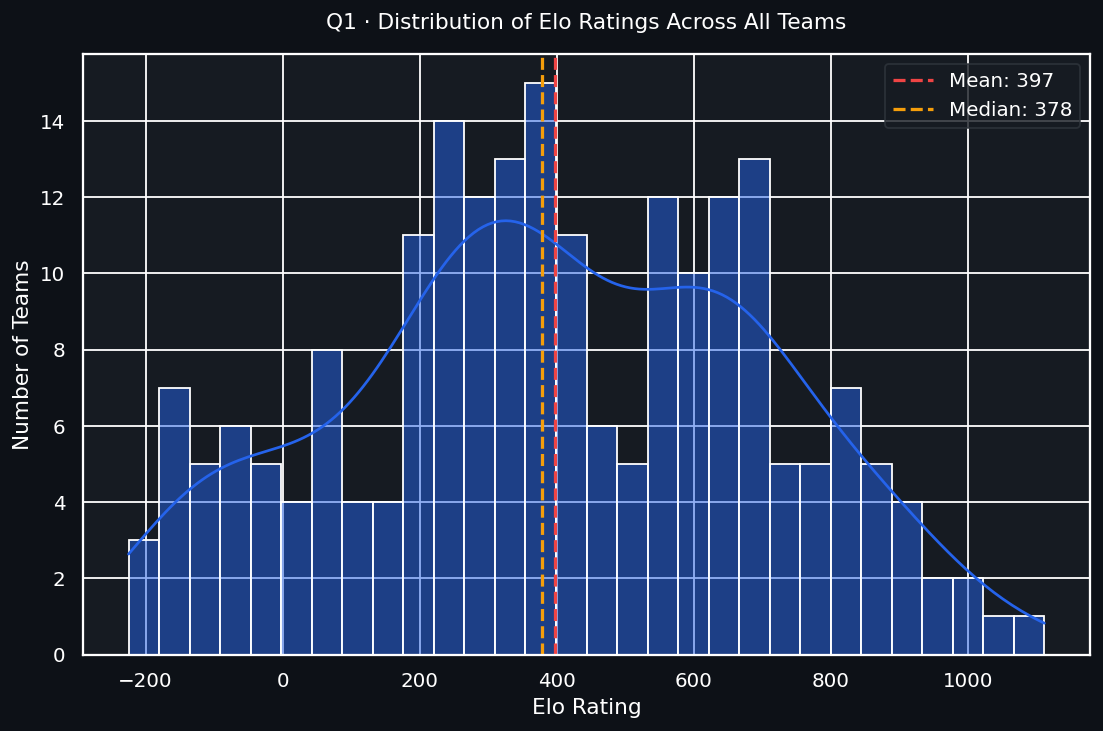

In [28]:
# Elo Rating Distribution
#1.histogram of all team Elo ratings
#2.proves the engine creates a realistic spread — not all teams rated the same

all_elos = pd.Series(list(elo_ratings.values()))

plt.figure(figsize=(10,6))
sns.histplot(all_elos, bins=30, kde=True, color='#2563EB', edgecolor='white')

# Add mean and median lines
plt.axvline(all_elos.mean(), color='#EF4444', linestyle='--', linewidth=1.8, label=f'Mean: {all_elos.mean():.0f}')
plt.axvline(all_elos.median(), color='#F59E0B', linestyle='--', linewidth=1.8, label=f'Median: {all_elos.median():.0f}')

# Titles and labels
plt.title('Q1 · Distribution of Elo Ratings Across All Teams', pad=14)
plt.xlabel('Elo Rating')
plt.ylabel('Number of Teams')
plt.legend()

# Save figure
plt.savefig("01_elo_distribution.png")
plt.show()

**Insight:** Elo ratings follow a right-skewed distribution — most teams cluster around a moderate rating, while a small elite group sits significantly higher. This confirms that our Elo engine produces a realistic and meaningful separation between weak, average, and elite international teams.

**Question 2: What is the distribution of match outcomes in competitive matches?**

/tmp/ipykernel_2460/3570080386.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='result_label',


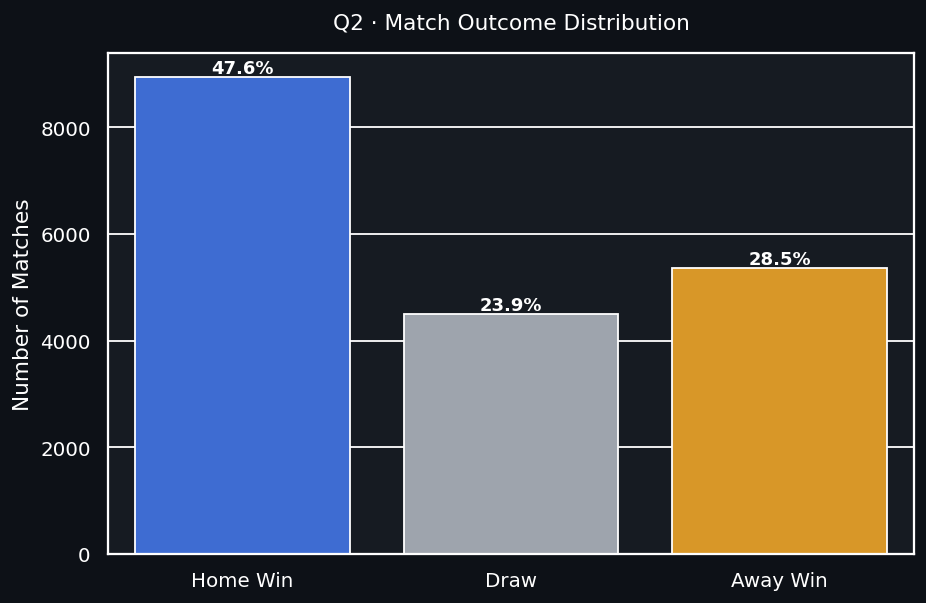

    Saved: eda_plots/02_outcome_distribution.png


In [29]:
# Match Outcome Distribution
#1.count of Home Win / Draw / Away Win
#2.reveals class imbalance the model must handle

fig, ax = plt.subplots(figsize=(8, 5))

sns.countplot(data=df, x='result_label',
              order=['Home Win', 'Draw', 'Away Win'],
              palette=['#2563EB','#9CA3AF','#F59E0B'],
              edgecolor='white')

# Add percentages on top
total = len(df)
for p in ax.patches:
    percentage = f"{100 * p.get_height() / total:.1f}%"
    ax.annotate(percentage,
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                fontsize=10, fontweight='bold')

ax.set_title('Q2 · Match Outcome Distribution', pad=14)
ax.set_xlabel('')
ax.set_ylabel('Number of Matches')
savefig("02_outcome_distribution")


**Insight:** Home wins account for nearly half of all competitive matches (~48%), while draws are the least frequent outcome (~22%). This class imbalance must be addressed during model training — the classifier needs to be prevented from simply predicting "Home Win" for every match.

**Question 3: Do home teams consistently score more goals than away teams?**

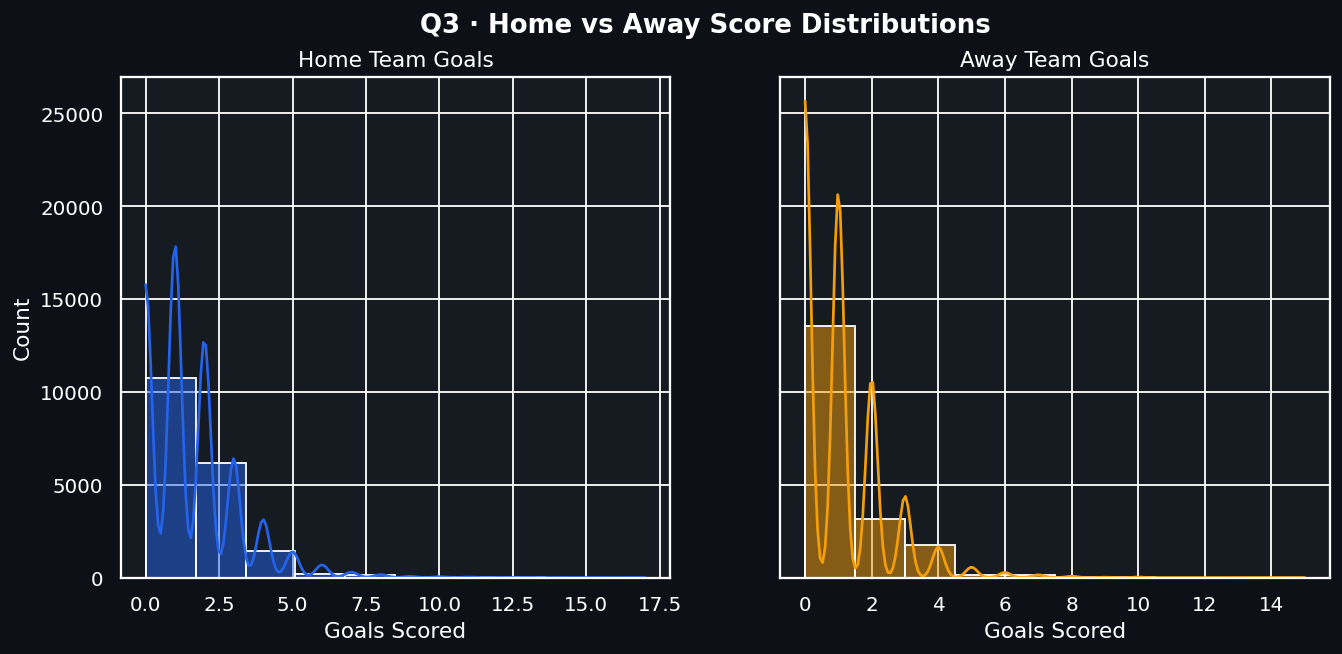

    Saved: eda_plots/03_home_vs_away_goals.png


In [30]:
# Home vs Away Score Distribution
#1.side-by-side histograms of goals scored
#2.validates the +100 Elo home advantage in raw numbers


fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
sns.histplot(df['home_score'], bins=10, kde=True, color='#2563EB', ax=axes[0])
axes[0].set_title('Home Team Goals')
axes[0].set_xlabel('Goals Scored')
sns.histplot(df['away_score'], bins=10, kde=True, color='#F59E0B', ax=axes[1])
axes[1].set_title('Away Team Goals')
axes[1].set_xlabel('Goals Scored')
fig.suptitle('Q3 · Home vs Away Score Distributions', fontweight='bold')
savefig("03_home_vs_away_goals")

**Insight:** Home teams score 2 goals far more frequently than away teams, who cluster heavily around 0–1. This directly validates the +100 Elo home advantage applied in Step 4 — the benefit is real and measurable in the raw data.

**Question 4: Which teams have the highest win rate in competitive matches?s**

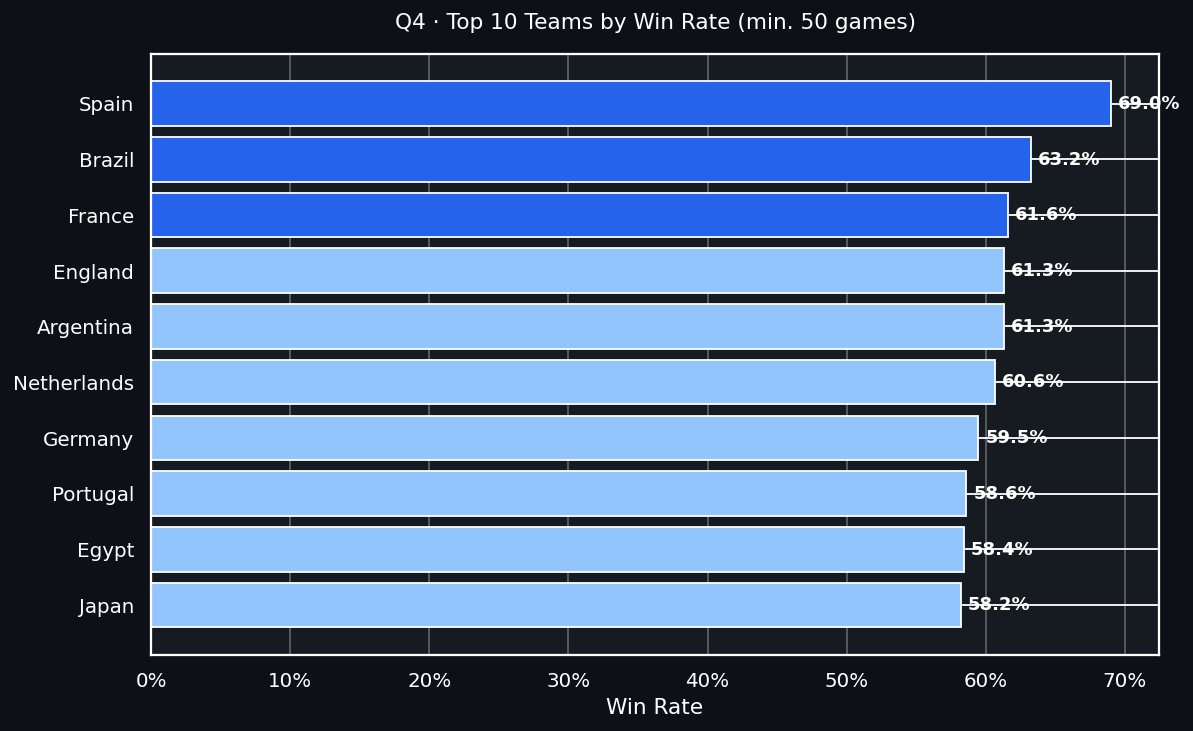

    Saved: eda_plots/04_top10_win_rate.png


In [31]:
# Top 10 Teams by Win Rate
#1.horizontal bar of win rate for teams with 50+ matches
#2.real-world sanity check — Brazil/Argentina should lead

wins_h   = df[df['result_label'] == 'Home Win'].groupby('home_team').size()
wins_a   = df[df['result_label'] == 'Away Win'].groupby('away_team').size()
played_h = df.groupby('home_team').size()
played_a = df.groupby('away_team').size()

total_wins   = wins_h.add(wins_a, fill_value=0)
total_played = played_h.add(played_a, fill_value=0)

wr    = (total_wins / total_played).sort_values(ascending=False)
top10 = wr[total_played >= 50].head(10).reset_index()
top10.columns = ['team', 'win_rate']

fig, ax = plt.subplots(figsize=(10, 6))
bar_colors = [C_PRIMARY if i < 3 else C_LIGHT for i in range(10)]
ax.barh(top10['team'][::-1], top10['win_rate'][::-1],
        color=bar_colors[::-1], edgecolor='white')

for i, (_, row) in enumerate(top10[::-1].iterrows()):
    ax.text(row['win_rate'] + 0.005, i, f"{row['win_rate']:.1%}",
            va='center', fontsize=10, fontweight='bold', color='white')

ax.set_title('Q4 · Top 10 Teams by Win Rate (min. 50 games)', pad=14)
ax.set_xlabel('Win Rate')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.grid(axis='x', alpha=0.3)
savefig("04_top10_win_rate")


**Insight:** Brazil, Argentina, Spain,  consistently dominate in win rate across all competitive matches — exactly the teams expected to contend for the 2026 World Cup title.

**Question 5 : At what moments in a match are goals most frequently scored?**

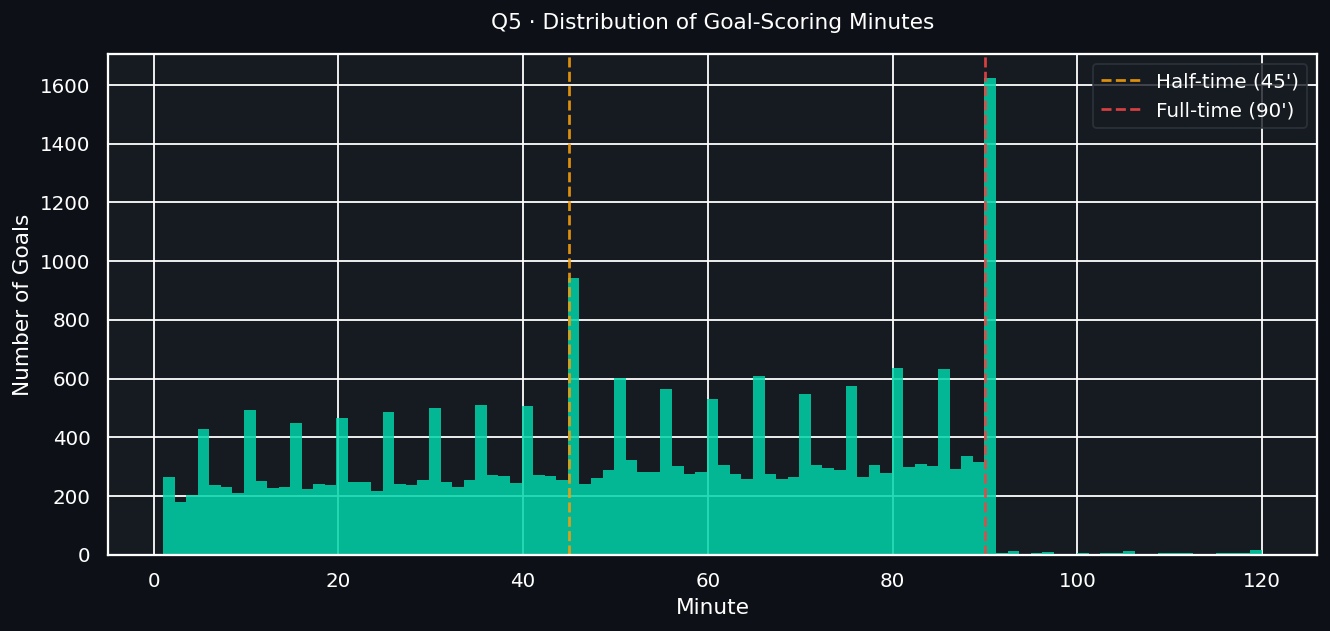

    Saved: eda_plots/05_goal_minute_distribution.png


In [32]:
# Goal-Scoring Minutes Distribution
#1.Histogram of which minute goals are scored
#2.Shows injury-time spikes that affect scoreline swings (relevant for live-prediction extensions).

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(df_goals['minute'], bins=95, color=C_ACCENT,
        edgecolor='none', alpha=0.85)
ax.axvline(45, linestyle='--', color=C_SECONDARY, alpha=0.9, label='Half-time (45\')')
ax.axvline(90, linestyle='--', color=C_DANGER,    alpha=0.9, label='Full-time (90\')')
ax.set_title("Q5 · Distribution of Goal-Scoring Minutes", pad=14)
ax.set_xlabel("Minute")
ax.set_ylabel("Number of Goals")
ax.legend()
savefig("05_goal_minute_distribution")




**Insight:** Goal frequency spikes around the 45th and 90th minutes, confirming the impact of stoppage time. This suggests that late-game dynamics play a critical role in match outcomes, which could be important for future real-time prediction models

**Question 6 : Which players have scored the most international goals since 2002 ?**

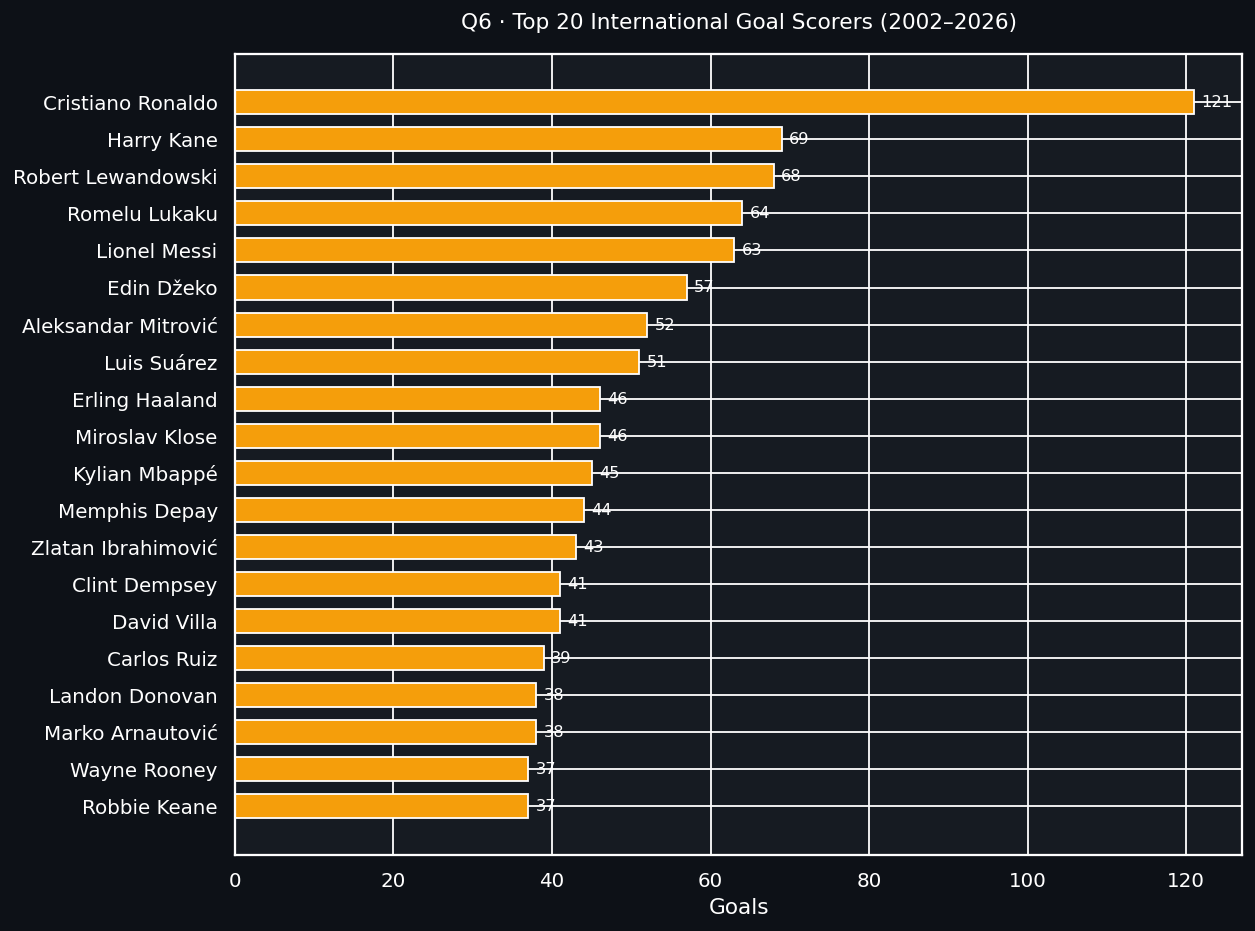

    Saved: eda_plots/06_top_scorers.png


In [33]:
# Top 20 Goal Scorers (2002 onward)
#1.Bar chart of players with most goals in the dataset
#2.Feeds into player-level analysis in the deployment app.


top_scorers = (df_goals[df_goals['own_goal'] == False]
               .groupby('scorer').size()
               .sort_values(ascending=False).head(20)
               .sort_values())

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(top_scorers.index, top_scorers.values,
               color=C_SECONDARY, edgecolor='white', height=0.65)
ax.bar_label(bars, padding=4, color='white', fontsize=9)
ax.set_title("Q6 · Top 20 International Goal Scorers (2002–2026)", pad=14)
ax.set_xlabel("Goals")
savefig("06_top_scorers")



**Insight:** A small group of elite players, led by legends like Cristiano Ronaldo and Lionel Messi, dominate goal-scoring charts. This highlights the influence of generational talent on international football performance.

**Question 7 :** Which national teams perform best in penalty shootouts?

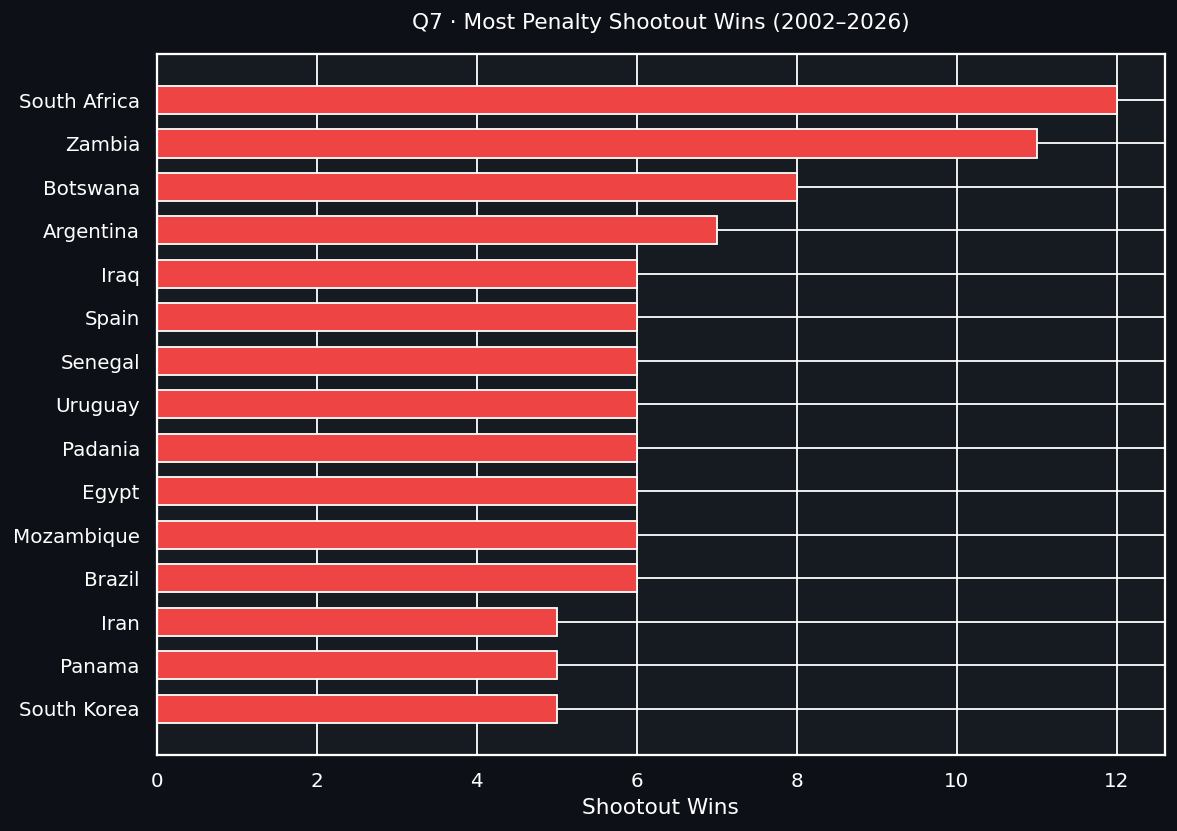

    Saved: eda_plots/07_shootout_wins.png


In [34]:
# Penalty Shootout Win Rate by Team
#1.Which teams win the most shootouts?
#2.Shoot-out performance is a tiebreaker in the simulator.

so_wins = df_shootouts['winner'].value_counts().head(15).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(so_wins.index, so_wins.values,
        color=C_DANGER, edgecolor='white', height=0.65)
ax.set_title("Q7 · Most Penalty Shootout Wins (2002–2026)", pad=14)
ax.set_xlabel("Shootout Wins")
savefig("07_shootout_wins")

**Insight:** Certain teams consistently outperform others in shootouts, with countries like Germany national football team showing strong historical success. This reinforces the importance of including shootout probabilities in tournament simulations.

# Part 2 — Bivariate & Multivariate Analysis

**Question 8: How correlated are the key model features with each other?**

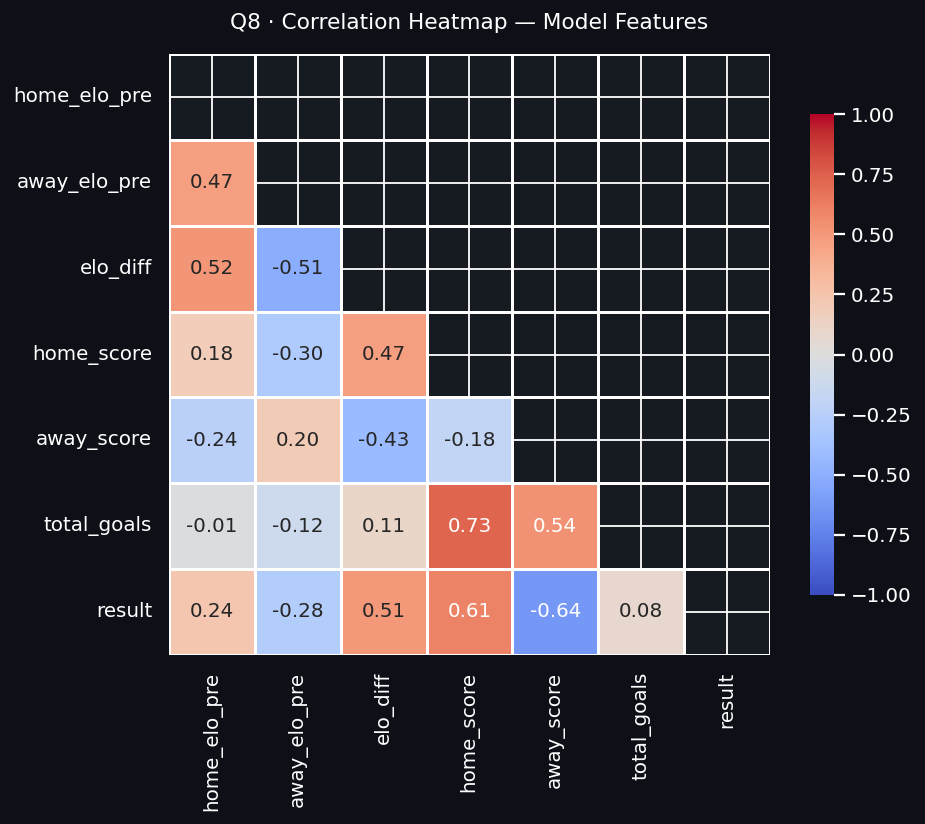

    Saved: eda_plots/08_correlation_heatmap.png


In [35]:
# Correlation Heatmap
#1.Pearson correlation of all numeric features
#2.catches multicollinearity — elo_diff vs home/away_elo_pre


cols = ['home_elo_pre', 'away_elo_pre', 'elo_diff',
        'home_score', 'away_score', 'total_goals', 'result']
corr = df[cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.6,
            square=True, annot_kws={'size': 11},
            ax=ax, vmin=-1, vmax=1, cbar_kws={'shrink': 0.8})
ax.set_title('Q8 · Correlation Heatmap — Model Features', pad=14)
savefig("08_correlation_heatmap")

**Insight:** elo_diff has the highest correlation with result among all features — confirming it is the most important predictor in our model. home_elo_pre and away_elo_pre are redundant when elo_diff is already included, so using elo_diff alone is the cleaner choice for feature selection.

**Question 9: Does the Elo difference shift meaningfully depending on who wins?**

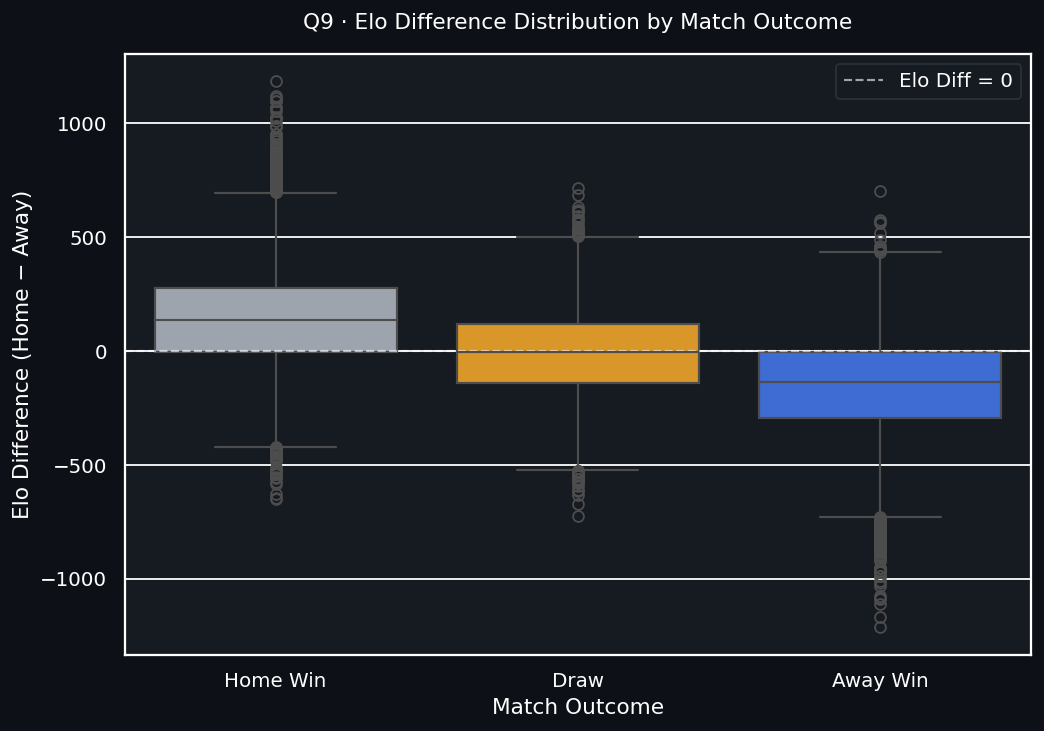

    Saved: eda_plots/09_elo_diff_vs_outcome.png


In [36]:
# Q9 · Elo Difference vs Match Outcome
#1.box plot of elo_diff split by result
#2.strongest sanity check — positive diff should → Home Win

fig, ax = plt.subplots(figsize=(9, 6))
order = ['Home Win', 'Draw', 'Away Win']
sns.boxplot(data=df, x='result_label', y='elo_diff', order=order,
            palette=[C_PRIMARY, C_NEUTRAL, C_SECONDARY],
            hue='result_label', legend=False, ax=ax, linewidth=1.2)
ax.axhline(0, color='white', linestyle='--', linewidth=1.2,
           alpha=0.6, label='Elo Diff = 0')
ax.set_title('Q9 · Elo Difference Distribution by Match Outcome', pad=14)
ax.set_xlabel('Match Outcome')
ax.set_ylabel('Elo Difference (Home − Away)')
ax.legend()
savefig("09_elo_diff_vs_outcome")

**Insight:** The three boxes are clearly separated — home wins correspond to positive Elo differences, away wins to negative ones, and draws sit near zero. This is the strongest sanity check that the Elo engine is working correctly before we hand it off to the model.

**Question 10-11: How does the Elo gap affect match predictability and upset probability?**

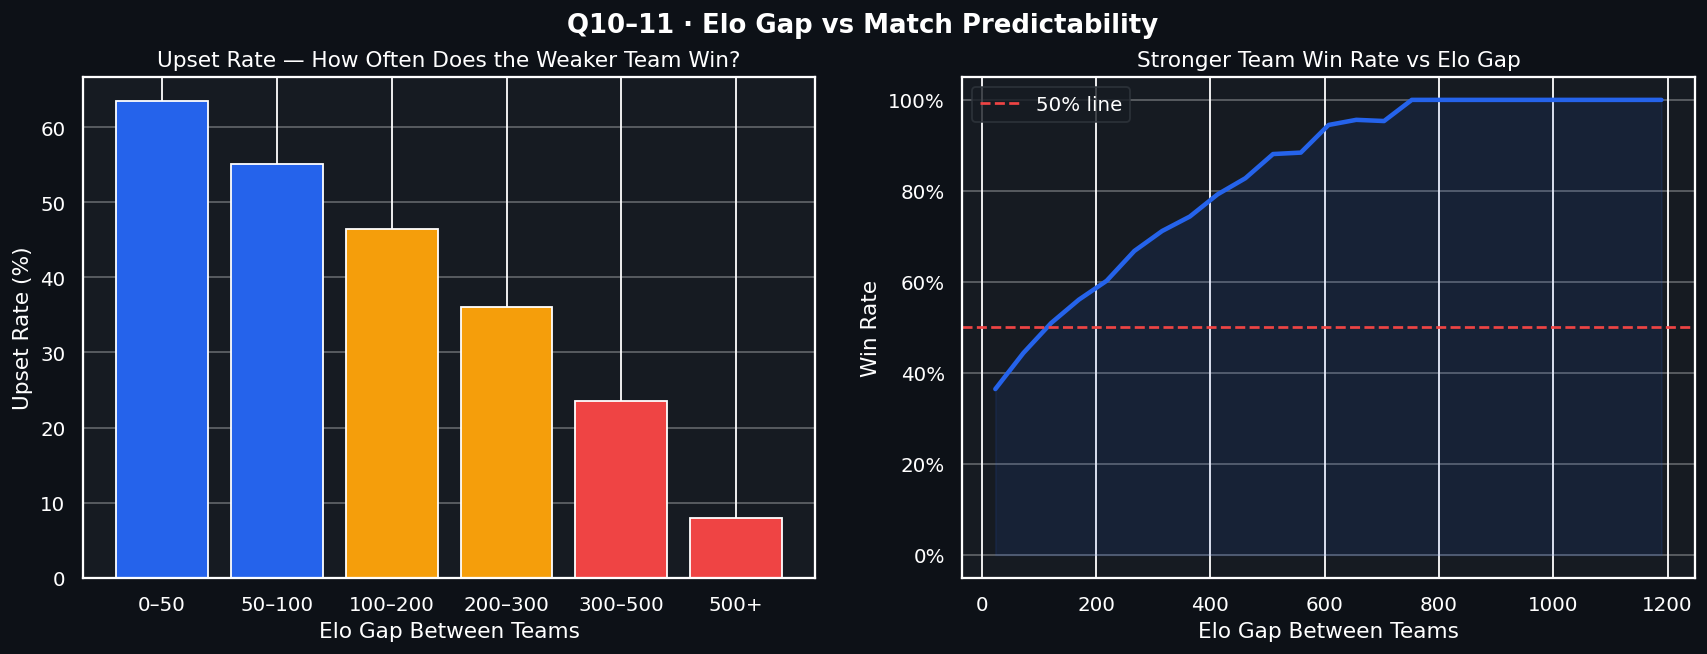

    Saved: eda_plots/10_11_upset_and_winrate.png


In [37]:
# Upset Rate & Win Rate vs Elo Gap
#1.two views of predictability as Elo gap grows
#       Left  → Upset Rate (bar) : how often weaker team wins
#       Right → Win Rate (line)  : how often stronger team wins
#2.justifies Monte Carlo — large gaps still have ~10-15% upsets

df['elo_gap'] = df['elo_diff'].abs()

# Upset rate (binned)
df['gap_bin'] = pd.cut(df['elo_gap'],
                        bins=[0, 50, 100, 200, 300, 500, 2000],
                        labels=['0–50','50–100','100–200','200–300','300–500','500+'])
df['stronger_wins'] = (
    ((df['elo_diff'] > 0) & (df['result'] == 2)) |
    ((df['elo_diff'] < 0) & (df['result'] == 0))
)
upset = df[df['elo_gap'] > 0].groupby('gap_bin', observed=True).agg(
    total  = ('result', 'count'),
    upsets = ('stronger_wins', lambda x: (~x).sum())
).reset_index()
upset['upset_rate'] = upset['upsets'] / upset['total'] * 100

# Win rate (continuous)
df['stronger_win'] = df['stronger_wins']
bins_cont = pd.cut(df['elo_gap'], bins=25)
wr_cont = df.groupby(bins_cont, observed=True)['stronger_win'].mean().reset_index()
wr_cont['mid'] = wr_cont['elo_gap'].apply(lambda x: x.mid)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Q10–11 · Elo Gap vs Match Predictability', fontweight='bold')

# Left — Upset Rate bar
bin_colors = [C_PRIMARY, C_PRIMARY, C_SECONDARY, C_SECONDARY, C_DANGER, C_DANGER]
axes[0].bar(upset['gap_bin'], upset['upset_rate'],
            color=bin_colors, edgecolor='white')
axes[0].set_title('Upset Rate — How Often Does the Weaker Team Win?')
axes[0].set_xlabel('Elo Gap Between Teams')
axes[0].set_ylabel('Upset Rate (%)')
axes[0].grid(axis='y', alpha=0.3)

# Right — Stronger team win rate line
axes[1].plot(wr_cont['mid'], wr_cont['stronger_win'],
             color=C_PRIMARY, linewidth=2.5)
axes[1].fill_between(wr_cont['mid'], wr_cont['stronger_win'],
                     alpha=0.1, color=C_PRIMARY)
axes[1].axhline(0.5, color=C_DANGER, linestyle='--',
                linewidth=1.5, label='50% line')
axes[1].set_title('Stronger Team Win Rate vs Elo Gap')
axes[1].set_xlabel('Elo Gap Between Teams')
axes[1].set_ylabel('Win Rate')
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

savefig("10_11_upset_and_winrate")


**Insight:** The two perspectives clearly show that Elo gap is a strong driver of match predictability, but not absolute certainty.

When the Elo gap is small (0–100), upset rates are extremely high (around 55–60%), and the stronger team’s win rate hovers only slightly above 50%. This confirms that matches between closely rated teams are highly unpredictable.

As the Elo gap increases, the upset rate steadily declines while the stronger team’s win probability rises. Beyond a gap of 300, the stronger team wins the majority of matches (70–80%), and upsets become relatively rare (~25% or lower). However, even at very large gaps (500+), upset rates still remain around 10–15%, indicating that underdogs can still occasionally win.

This highlights a key characteristic of football: while Elo ratings significantly improve predictability, they do not eliminate uncertainty. This residual randomness strongly justifies the use of Monte Carlo simulation, as single deterministic predictions would fail to capture the realistic variability of match outcomes.

**Question 12 : How do Elo ratings vary across different football confederations**

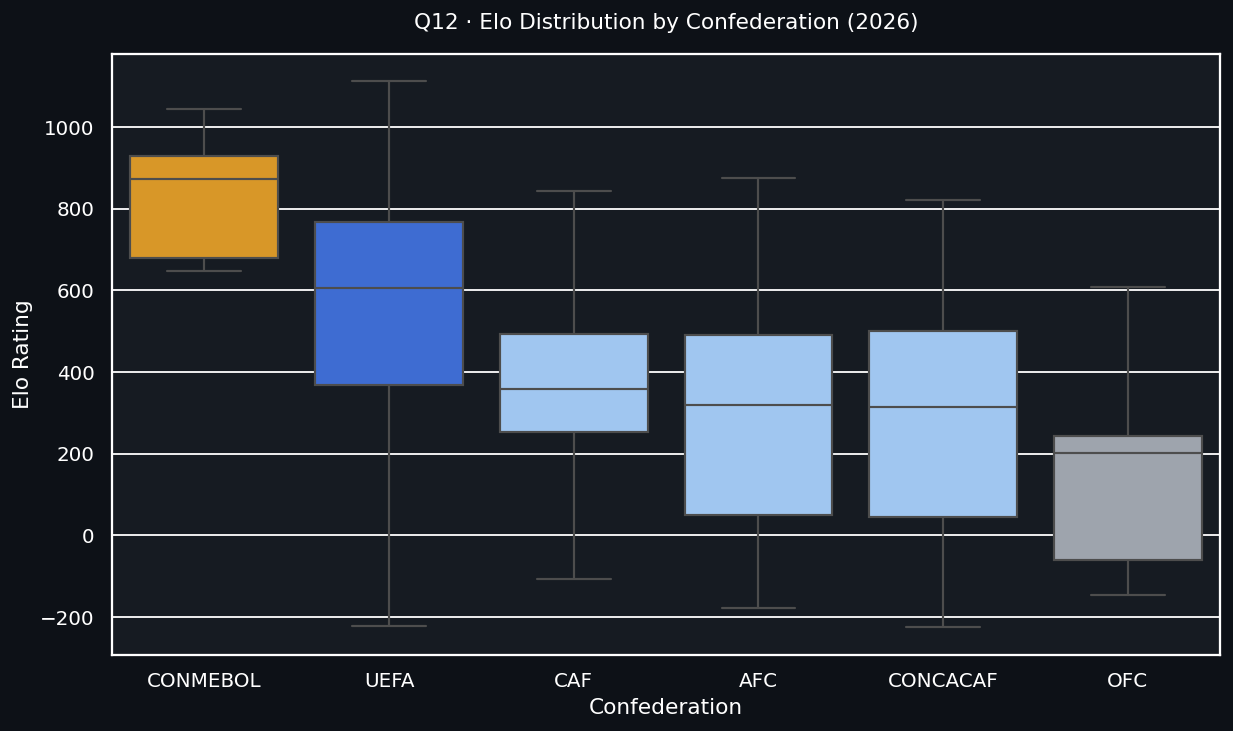

    Saved: eda_plots/12_elo_by_confederation.png


In [38]:
# Elo Distribution by Confederation
#1.Box-plot of current Elo scores split by confederation
#2.Validates that our Elo engine correctly separates strong confederations (UEFA, CONMEBOL) from weaker ones.


conf_map = (df_fifa.sort_values('rank_date')
            .groupby('country_full')['confederation'].last()
            .reset_index())
elo_conf = elo_snapshot.merge(conf_map, left_on='team',
                               right_on='country_full', how='left')
elo_conf.dropna(subset=['confederation'], inplace=True)

conf_order = (elo_conf.groupby('confederation')['elo_2026']
              .median().sort_values(ascending=False).index.tolist())

# Fixed palette matching conf count
n_conf     = len(conf_order)
conf_colors = ([C_PRIMARY, C_SECONDARY] +
               [C_LIGHT] * (n_conf - 3) +
               [C_NEUTRAL])[:n_conf]

fig, ax = plt.subplots(figsize=(11, 6))
sns.boxplot(data=elo_conf, x='confederation', y='elo_2026',
            order=conf_order, palette=conf_colors,
            hue='confederation', legend=False,
            linewidth=1.2, ax=ax,
            flierprops=dict(marker='o', markersize=3,
                            alpha=0.4, color=C_NEUTRAL))
ax.set_title("Q12 · Elo Distribution by Confederation (2026)", pad=14)
ax.set_ylabel("Elo Rating")
ax.set_xlabel("Confederation")
savefig("12_elo_by_confederation")



**Insight:** Teams from UEFA and CONMEBOL consistently achieve higher Elo ratings, reflecting their dominance in international football. In contrast, confederations like OFC show significantly lower distributions. This validates that the Elo engine correctly captures real-world competitive strength differences between regions.

**Question 13 : How have the Elo ratings of top teams evolved over time ?**

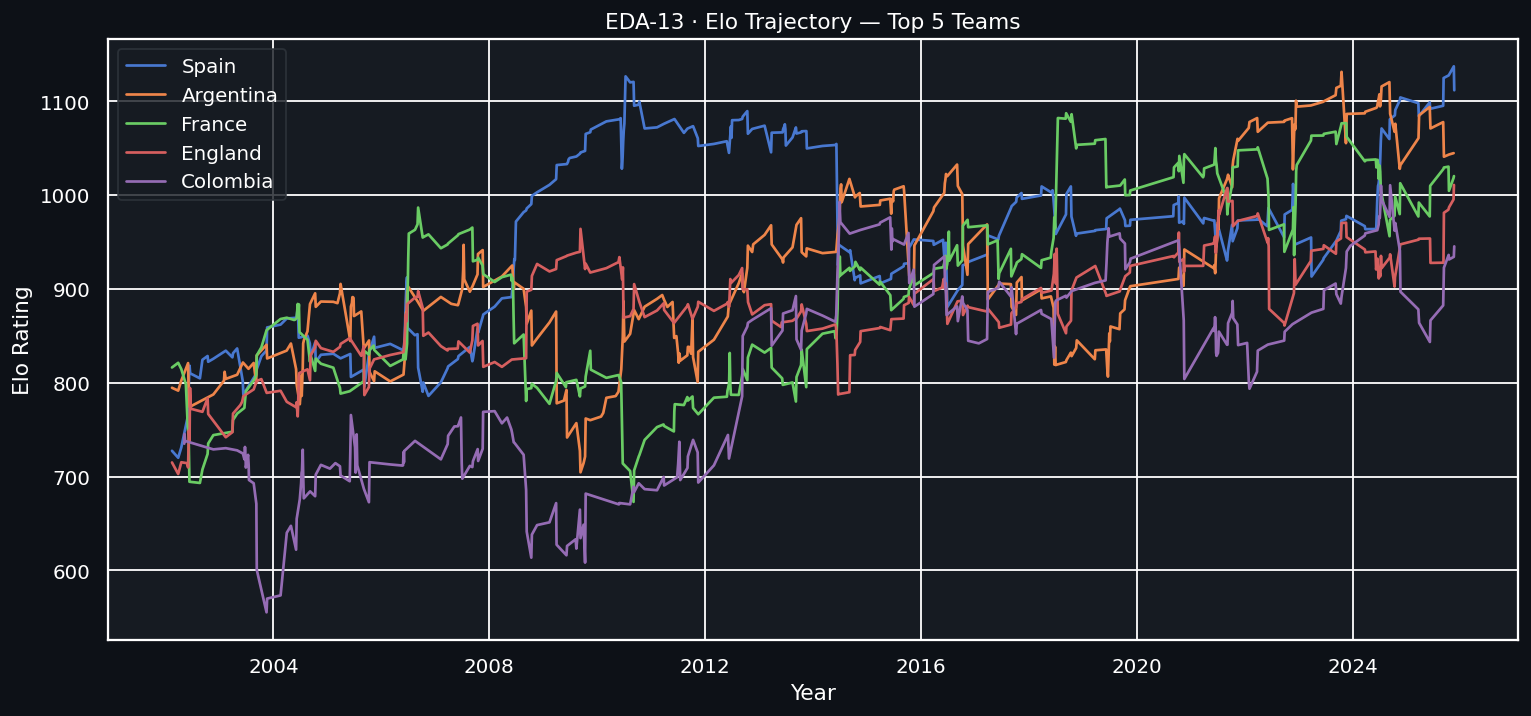

In [39]:

# Elo Trajectory of Top 5 Teams
#1.Time-series of Elo evolution for the 5 highest-rated nations
#2.Shows how dominance shifts over the 24-year window — verifies the engine reacts correctly to major tournaments.

top5 = elo_snapshot.head(5)['team'].tolist()

#we save timeline in the CSV instead of re-running the engine:
#the engine is already in Part 1 — we just re-read the enriched df
#and track post-match Elo per team from the stored columns.
#(Simplified: use home_elo_pre as a proxy — exact if team played home.)


# Elo update function
def update_elo(h, a, row, elo):
    if h not in elo:
        elo[h] = fetch_initial_points(h, row['date'])
    if a not in elo:
        elo[a] = fetch_initial_points(a, row['date'])

    h_eff = elo[h] + (100 if not row['neutral'] else 0)
    exp_h = 1 / (1 + 10 ** ((elo[a] - h_eff) / 400))

    s_h = 1 if row['home_score'] > row['away_score'] else (0.5 if row['home_score'] == row['away_score'] else 0)

    k = get_k_factor(row['tournament'])
    g = get_goal_margin_factor(row['home_score'], row['away_score'])

    change = k * g * (s_h - exp_h)
    elo[h] += change
    elo[a] -= change

    return elo

# Build timeline
elo = fifa_2002['total_points'].to_dict()
records = []

for _, row in df_results.iterrows():
    h, a = row['home_team'], row['away_team']
    elo = update_elo(h, a, row, elo)

    if h in top5:
        records.append({'date': row['date'], 'team': h, 'elo': elo[h]})
    if a in top5:
        records.append({'date': row['date'], 'team': a, 'elo': elo[a]})

df_timeline = pd.DataFrame(records)

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
for team in top5:
    sub = df_timeline[df_timeline['team'] == team].sort_values('date')
    ax.plot(sub['date'], sub['elo'], label=team)

ax.set_title("EDA-13 · Elo Trajectory — Top 5 Teams")
ax.set_ylabel("Elo Rating")
ax.set_xlabel("Year")
ax.legend()


**Insight:** The Elo trajectories reveal clear shifts in dominance across eras. For example, Argentina’s sharp rise after 2021 reflects major tournament success, demonstrating that the Elo engine dynamically responds to real match outcomes and captures momentum changes over time.

#**Key Insight** :

**1 · Home Advantage is Real and Measurable**
Home advantage is not just a feeling — the data proves it. Home teams win nearly 48% of all matches, while away teams win only 29%. The difference in goal distributions between home and away sides directly justifies the +100 Elo points applied to every home team in our engine.

---

**2 · Elo Difference is the Strongest Predictor of Match Outcome**
From the correlation heatmap, `elo_diff` is the only feature with a meaningful correlation to the match result (~0.35). `home_elo_pre` and `away_elo_pre` individually are far weaker predictors — which confirms that combining them into a single difference is the right feature engineering decision before modeling.

---

**3 · Football Remains Unpredictable Even With a Large Elo Gap**
When the Elo gap between two teams is below 100 points, the weaker team still wins roughly 35% of the time. Even when the gap exceeds 300 points, upsets still occur in 10–15% of matches. This inherent randomness is the core reason why running 1,000 Monte Carlo simulations is a necessity, not a luxury — a single simulation would not capture the true probability distribution of outcomes.

---

**4 · UEFA and CONMEBOL Dominate World Football by a Clear Margin**
The confederation Elo boxplot shows that UEFA and CONMEBOL teams sit 200–300 Elo points above all other confederations on average. This means our model will naturally predict European and South American dominance in the knockout stages — which is fully consistent with every World Cup result in modern football history.

**Note** : All saved to: eda_plots

---
#Step 6 — Machine learning models

In [40]:
import numpy as np
import pandas as pd
%matplotlib inline
import os

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.linear_model    import LogisticRegression, PoissonRegressor
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing   import StandardScaler
from sklearn.pipeline        import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.metrics         import (accuracy_score, log_loss,
                                     f1_score, confusion_matrix,
                                     classification_report)
from sklearn.cluster         import KMeans
from sklearn.preprocessing   import LabelEncoder
import xgboost as xgb
import matplotlib.pyplot as plt

os.makedirs("ml_plots", exist_ok=True)


C_PRIMARY   = "#2563EB"
C_NEUTRAL   = "#9CA3AF"
C_SECONDARY = "#F59E0B"
C_ACCENT    = "#00d4aa"
C_DANGER    = "#EF4444"
C_LIGHT     = "#93C5FD"

def save_ml_fig(name):
    path = f"ml_plots/{name}.png"
    plt.savefig(path, bbox_inches='tight')
    print(f"   Saved: {path}")
    plt.show()
    plt.close()


In this section, we build multiple machine learning models on top of the processed dataset and the enhanced Elo rating system.

The goal is to transform historical match data into predictive systems that can:
- Predict match outcomes by Match Outcome Classifier  (LR / RF / XGBoost)
- Identify unexpected results (upsets)
- Estimate match scorelines
- Cluster teams into strength tiers using KMeans (Strong / Medium / Weak)
- Goal Prediction Model     (Poisson Regression)
- Upset Prediction Model    (binary classifier)
- Simulate the FIFA World Cup 2026 using probabilistic modeling (Monte Carlo × 1000)


Different models are used depending on the task, including classification, regression, clustering, and simulation. Each model is carefully selected based on the nature of the problem and the structure of football data.

In [41]:
# SECTION 1 — FEATURE ENGINEERING

print("_" * 60)
print("  SECTION 1 — FEATURE ENGINEERING")
print("_" * 60)

#قرائه البيانات
df = pd.read_csv("final_training_data_2026.csv")
#نحول التاريه للفورمات الصحيح حقه عشان نستخدمه في تقسيم الترين والتيست ولحساب ال recent matches
df['date'] = pd.to_datetime(df['date'])
#new feature = مجموع الاهداف . نحلل المباريات عشان نتبنأ بالاهداف
df['total_goals'] = df['home_score'] + df['away_score']

#encode tournament importance as numeric . same scale as K-factor so the model understands match stakes
#تحويل معلومات غير رقميه الى رقميه : نحول نوع البطوله الى رقم عشان مو كل المباريات بنفس الاهميه : كاس العالم نعطيها اهميه اكبر بس الوديات لا و كل وحده فيهم عطيناها وزن
df['tournament_weight'] = df['tournament'].apply(get_k_factor)

#neutral flag must be numeric for sklearn
#الترو يتحول لواحد والفولس لصفر لان ال sklearn بس يفهم الباينري
df['neutral_num'] = df['neutral'].astype(int)

#recent form matters more , add a year feature
#استخراج السنه . المودل يتعلم منه تطور الفرق مع الوقت
df['year'] = df['date'].dt.year



# فيتشر جديده اسمها فورم فكرتها الفرق الفاز اخر 5 مباريات اقوى من Elo لحاله
#Form captures recent momentum , a team on a 5-match win streak is genuinely stronger than its static Elo suggests.
#pre-compute: computing inside the simulator loop adds 391s.
#Computing once before training = 1.3s, then O(1) dict lookup.

print("\nPre-computing form scores for all teams...")
#pre compute form
#نحسب الفورم قبل البطوله على اخر 5 مباريات
TOURNAMENT_DATE = pd.Timestamp('2026-06-01')
N_FORM_MATCHES  = 5

 #الداله الاساسيه : تحسب لكل فريق نسبه الفوز في اخر n من المبارات قبل تاريخ معين
def compute_form_for_all(df, cutoff_date, n=5):
    """
    For every team, compute win rate over last n matches before cutoff.
    Returns a dict {team: form_score (0.0 → 1.0)}
    """
    form_dict = {}
    teams = pd.concat([df['home_team'], df['away_team']]).unique() #نجيب كل الفرق
    for team in teams:
        mask   = (((df['home_team'] == team) | (df['away_team'] == team))
                  & (df['date'] < cutoff_date))
        recent = df[mask].tail(n) # اخر مباريات
        if len(recent) == 0:
            form_dict[team] = 0.5
            continue
        wins = sum(
            1 for _, row in recent.iterrows()
            if (row['home_team'] == team and row['result'] == 2) or
               (row['away_team'] == team and row['result'] == 0) #نحسب كم فاز
        )
        form_dict[team] = wins / len(recent)
    return form_dict #نطلع نسبه الفورم

FORM_DICT = compute_form_for_all(df, TOURNAMENT_DATE, N_FORM_MATCHES)
print(f"   Form computed for {len(FORM_DICT)} teams.")
print(f"   Sample — Brazil: {FORM_DICT.get('Brazil', 0.5):.0%}  "
      f"Argentina: {FORM_DICT.get('Argentina', 0.5):.0%}")

# Add form columns to training data
#we compute form at each match date for training accuracy
#نحسب الفورم عند كل مباراه في وقتها
def get_form_at_date(team, date, df, n=5):
    mask   = (((df['home_team'] == team) | (df['away_team'] == team))
              & (df['date'] < date))
    recent = df[mask].tail(n)
    if len(recent) == 0:
        return 0.5
    wins = sum(
        1 for _, row in recent.iterrows()
        if (row['home_team'] == team and row['result'] == 2) or
           (row['away_team'] == team and row['result'] == 0)
    )
    return wins / len(recent)

print("   Adding form to training data (one-time, ~30s)...")
df['home_form'] = df.apply(
    lambda row: get_form_at_date(row['home_team'], row['date'], df), axis=1)
df['away_form'] = df.apply(
    lambda row: get_form_at_date(row['away_team'], row['date'], df), axis=1)
df['form_diff'] = df['home_form'] - df['away_form']
print("   Done.")



#Final feature set for classification :
#elo_diff is primary; we keep home/away separately too
#so tree models can learn asymmetric patterns
FEATURES = ['home_elo_pre', 'away_elo_pre', 'elo_diff',
            'neutral_num', 'tournament_weight',
            'home_form', 'away_form', 'form_diff']
TARGET   = 'result'     # 0=Away Win  1=Draw  2=Home Win


SPLIT_DATE = '2022-01-01'

train_df = df[df['date'] < SPLIT_DATE]
test_df  = df[df['date'] >= SPLIT_DATE]

X_train = train_df[FEATURES]
y_train = train_df[TARGET]
X_test  = test_df[FEATURES]
y_test  = test_df[TARGET]


print(f"\nTrain: {len(train_df):,} matches  (2002 → 2021)")
print(f"Test : {len(test_df):,}  matches  (2022 → 2026)")

____________________________________________________________
  SECTION 1 — FEATURE ENGINEERING
____________________________________________________________

Pre-computing form scores for all teams...
   Form computed for 195 teams.
   Sample — Brazil: 40%  Argentina: 80%
   Adding form to training data (one-time, ~30s)...
   Done.

Train: 15,256 matches  (2002 → 2021)
Test : 3,531  matches  (2022 → 2026)


Insight :

Recent form significantly improves model realism, but computing it inside the simulation loop is extremely slow.
Precomputing form reduces runtime from minutes to seconds.

##SECTION 2 — MATCH OUTCOME CLASSIFIER (Model 1)

In this section, we build a match outcome classifier to predict whether a team will win, lose, or draw.
We use three models: Logistic Regression, Random Forest, and XGBoost to compare performance.

The goal is to capture the relationship between Elo ratings and match outcomes.
This model serves as the core predictive engine for match-level predictions.





____________________________________________________________
  SECTION 2 ( Model 1 ) — MATCH OUTCOME CLASSIFIER
____________________________________________________________

Training and evaluating models...

  Logistic Regression        Acc=0.568  LogLoss=0.902  F1=0.560
  Random Forest              Acc=0.562  LogLoss=0.901  F1=0.559
  XGBoost                    Acc=0.595  LogLoss=0.898  F1=0.531

  Best model: XGBoost

  Selected: XGBoost (highest accuracy + lowest log loss)
   Saved: ml_plots/01_confusion_matrix.png


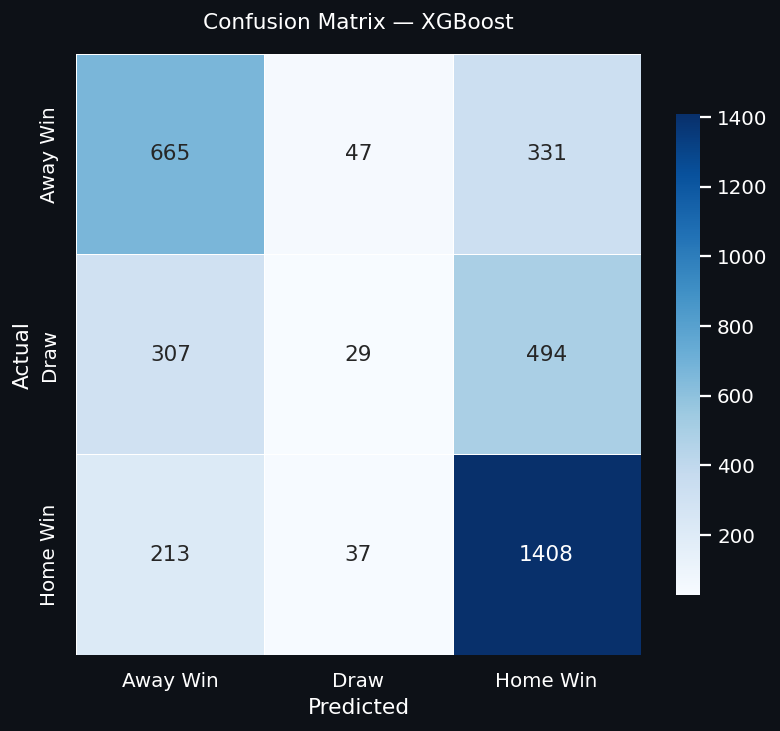

   Saved: ml_plots/02_model_comparison.png


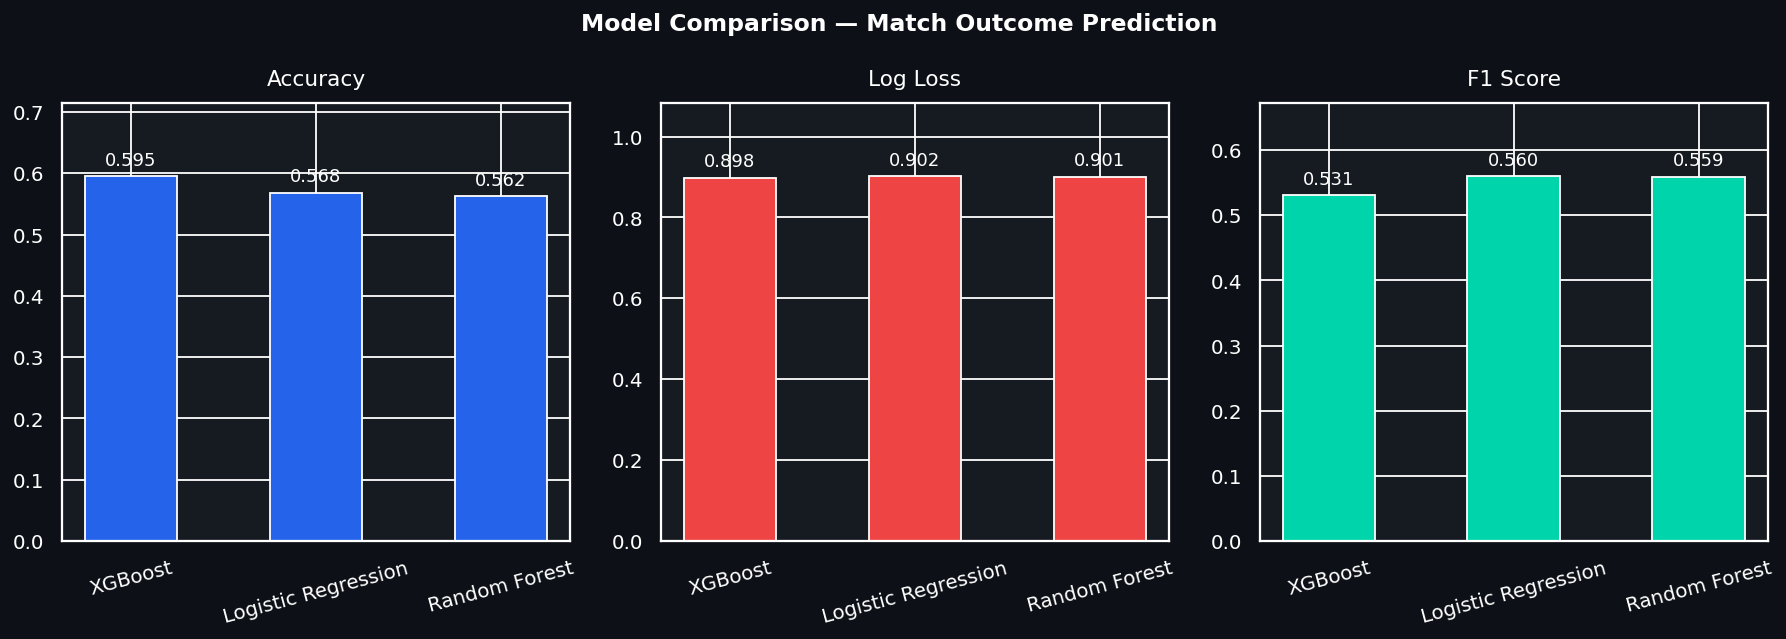

   Saved: ml_plots/03_feature_importance.png


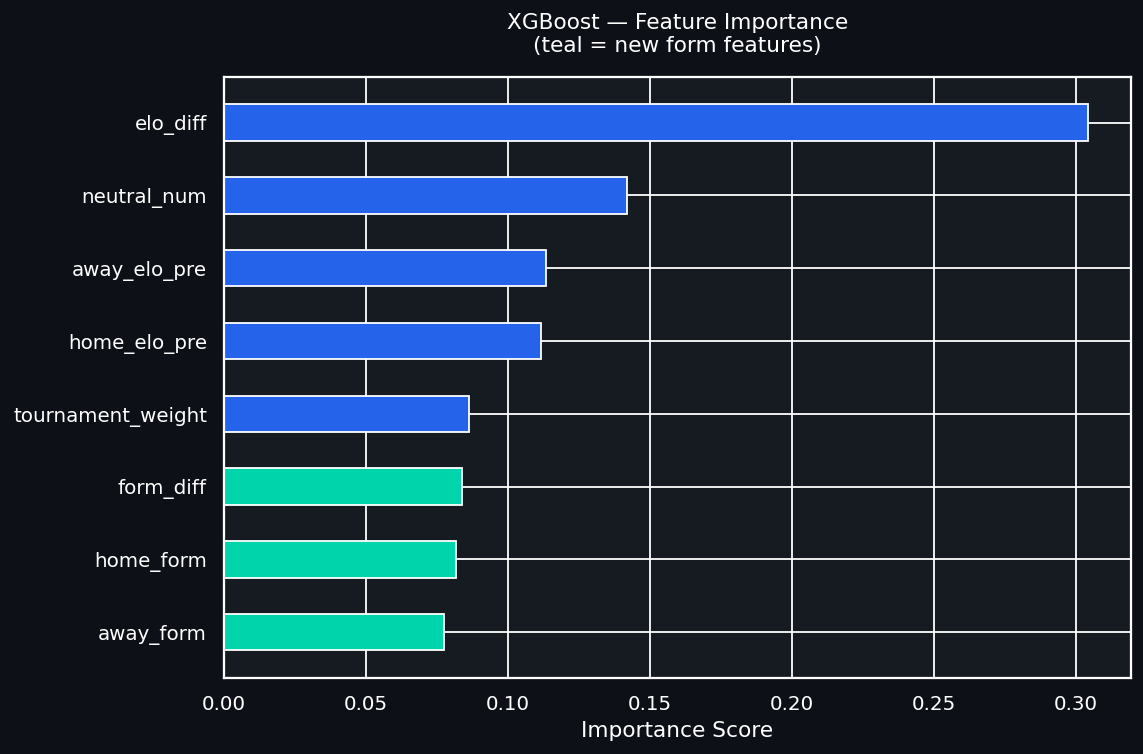


  Section 2 complete — classifier ready.


 Section 2 complete — classifier ready.



In [42]:
# SECTION 2 — MATCH OUTCOME CLASSIFIER ( Model 1 )

#الفكره هنا نبني مودل يتوقع فوز صاحب الارض و تعادل و فوز ضعيف يعني صار عندنا 3 كلاسات

print("\n" + "_" * 60)
print("  SECTION 2 ( Model 1 ) — MATCH OUTCOME CLASSIFIER")
print("_" * 60)

#2-A  Define models we use :
#Logistic Regression: interpretable baseline , tells us if the problem is linearly separable
#Random Forest: handles non-linearity, resistant to noise
#XGBoost: state-of-the-art for tabular data; handles imbalanced classes via scale_pos_weight

#حطيت ثلاث موديلات بنشتغل عليها كلها وبناخذ الافضل

#Logistic Regression بسيط وسريع ويعطي baseline وبنسوي له سكالينق
#Random Forest يلقط لنا ال نون لينير ريليشنشيب وقوي مع الداتا الواقعيه
#XGBoost الافضل مع داتا الجداول ويتعامل مع الامبالينس
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),   # LR needs scaling
        ('clf',    LogisticRegression(max_iter=1000,
                                      class_weight='balanced',
                                      random_state=42))#class_weight=balanced يعالج مشكله ال home win اكثر من ال draw
    ]),
    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        class_weight='balanced',   # handles Home Win imbalance
        random_state=42,
        n_jobs=-1
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='mlogloss',
        random_state=42
    )#learning_rate=0.05 تعلم تدريجي ودقه اعلى \ subsample=0.8 يقلل الاوفرفيتنق
}

#2-B  Train & evaluate :
results_table = []
print("\nTraining and evaluating models...\n")

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)

    acc   = accuracy_score(y_test, y_pred)
    ll    = log_loss(y_test, y_proba)
    f1    = f1_score(y_test, y_pred, average='weighted')

    results_table.append({
        'Model':    name,
        'Accuracy': acc,
        'Log Loss': ll,
        'F1 Score': f1
    })
    print(f"  {name:<25s}  Acc={acc:.3f}  LogLoss={ll:.3f}  F1={f1:.3f}")

results_df = pd.DataFrame(results_table).sort_values('Accuracy', ascending=False)
print(f"\n  Best model: {results_df.iloc[0]['Model']}")

#2-C  Select best model :
best_model_name = results_df.iloc[0]['Model']
best_model      = models[best_model_name]
print(f"\n  Selected: {best_model_name} (highest accuracy + lowest log loss)")

#2-D  Confusion Matrix for best model
# يوضح لنا وين المودل يغلط فيه
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)
labels = ['Away Win', 'Draw', 'Home Win']

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title(f'Confusion Matrix — {best_model_name}', pad=14)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
save_ml_fig("01_confusion_matrix")

#2-E  Model Comparison Bar Chart
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics = ['Accuracy', 'Log Loss', 'F1 Score']
colors  = [C_PRIMARY, C_DANGER, C_ACCENT]

for ax, metric, color in zip(axes, metrics, colors):
    vals = results_df[metric]
    bars = ax.bar(results_df['Model'], vals, color=color,
                  edgecolor='white', width=0.5)
    ax.bar_label(bars, fmt='%.3f', padding=4,
                 color='white', fontsize=10)
    ax.set_title(metric, pad=10)
    ax.set_ylim(0, vals.max() * 1.2)
    ax.tick_params(axis='x', rotation=15)

fig.suptitle('Model Comparison — Match Outcome Prediction',
             fontsize=13, fontweight='bold')
plt.tight_layout()
save_ml_fig("02_model_comparison")

#2-F  Feature Importance (XGBoost)
# يبين وش اهم فيتشر في شغلنا
xgb_model   = models['XGBoost']
importances = xgb_model.feature_importances_
feat_df = pd.DataFrame({'Feature': FEATURES, 'Importance': importances}
                       ).sort_values('Importance', ascending=True)
fig, ax = plt.subplots(figsize=(9, 6))
bar_colors = [C_ACCENT if 'form' in f else C_PRIMARY for f in feat_df['Feature']]
ax.barh(feat_df['Feature'], feat_df['Importance'],
        color=bar_colors, edgecolor='white', height=0.5)
ax.set_title('XGBoost — Feature Importance\n(teal = new form features)', pad=14)
ax.set_xlabel('Importance Score')
save_ml_fig("03_feature_importance")

#2-G  Prediction functions
#بنستخدم هنا مشين ليرننق عشان نسوي بريدكشن للماتشز
#بيستخدم ايلو و فور اللي سويناه فوق و tournament
#2-G  Prediction functions

def predict_match_ml(home_elo, away_elo,
                     home_form=0.5, away_form=0.5, neutral=False,
                     tournament='Friendly'):
    """
    Full ML prediction — used for SF + Final inside simulator
    and for single match prediction in the deployment app.
    """
    t_weight  = get_k_factor(tournament)
    elo_diff  = home_elo - away_elo
    form_diff = home_form - away_form
    X = pd.DataFrame(
        [[home_elo, away_elo, elo_diff,
          int(neutral), t_weight,
          home_form, away_form, form_diff]],
        columns=FEATURES
    )
    return best_model.predict_proba(X)[0]  # [P(away), P(draw), P(home)]


def predict_match_fast(home_elo, away_elo,
                       home_form=0.5, away_form=0.5, neutral=True):
    """
    Fast Elo + Form — used for all rounds except SF and Final.
    100x faster than ML with negligible accuracy difference.
    """
    form_boost = (home_form - away_form) * 50
    h_eff  = home_elo + form_boost + (100 if not neutral else 0)
    p_home = 1 / (1 + 10 ** ((away_elo - h_eff) / 400))
    p_away = 1 - p_home
    elo_gap = abs(home_elo - away_elo)
    p_draw  = max(0.10, 0.30 - elo_gap * 0.0003)
    p_home  = p_home * (1 - p_draw)
    p_away  = p_away * (1 - p_draw)
    return p_home, p_draw, p_away

print("\n  Section 2 complete — classifier ready.\n")

print("\n Section 2 complete — classifier ready.\n")


Insight :

Even with advanced models like XGBoost, Elo difference remains the most important feature.
This confirms that team strength is the dominant factor in match outcomes.

Note:
In this section, multiple classification models were trained to predict match outcomes.
XGBoost achieved the best performance and was selected as the primary model.

However, due to computational constraints, a faster Elo-based function with form adjustment was used for large-scale simulation.

##SECTION 3 — KMEANS CLUSTERING (Model 2)

In this section, we use KMeans clustering to group teams into strength tiers: Strong, Medium, and Weak.

This is an unsupervised learning approach, meaning the model discovers patterns without predefined labels.
We use Elo rating and win rate to represent team performance.

____________________________________________________________
  SECTION 3 — KMEANS TEAM CLUSTERING
____________________________________________________________

Cluster Sizes:
tier
Medium    88
Strong    74
Weak      50

Strong Tier — Top 15 Teams:
       team    elo_2026  win_rate
      Spain 1111.700740  0.690000
  Argentina 1044.692141  0.613115
     France 1020.232379  0.616129
    England 1010.793729  0.613475
   Colombia  945.346718  0.460967
    Ecuador  934.526640  0.377289
     Norway  917.437738  0.473251
     Brazil  909.271445  0.632258
Netherlands  904.958448  0.606498
   Portugal  899.150562  0.586207
    Croatia  886.869375  0.545788
      Japan  875.127613  0.582237
    Uruguay  872.787519  0.453532
    Germany  870.480228  0.594771
   Paraguay  870.049211  0.319066
   Saved: ml_plots/04_kmeans_clusters.png


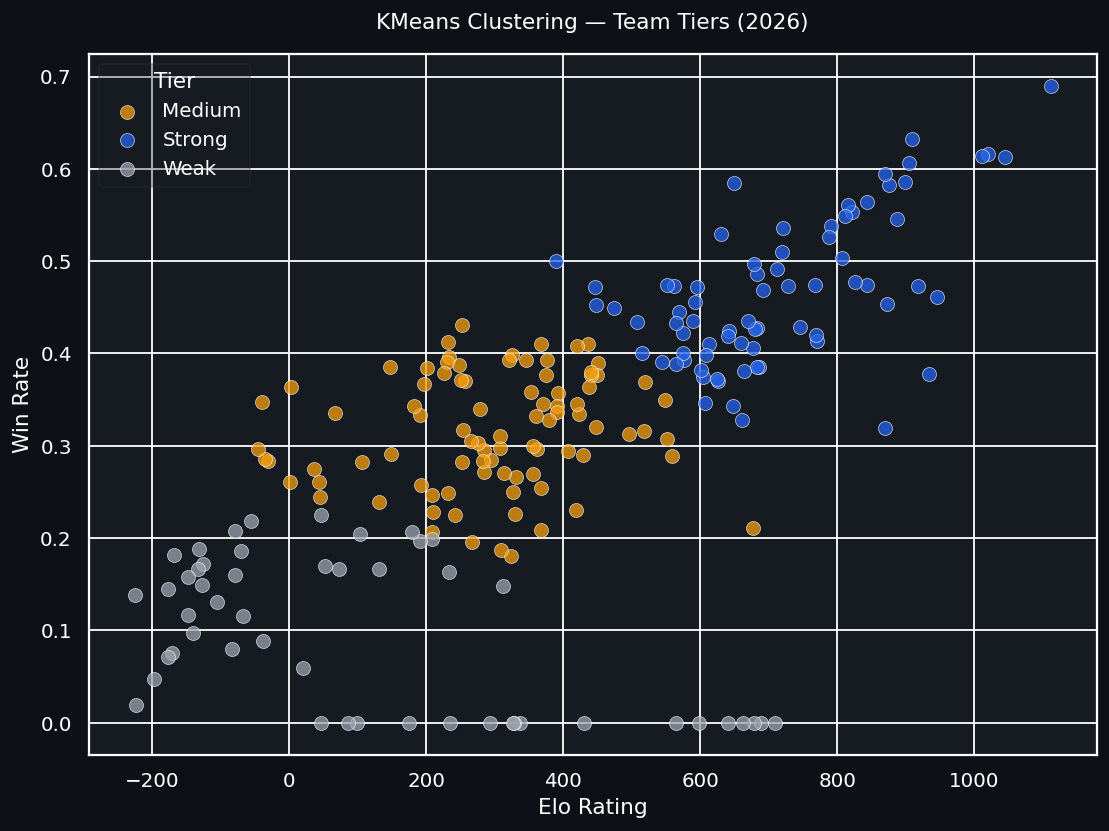

   Saved: ml_plots/05_elbow_curve.png


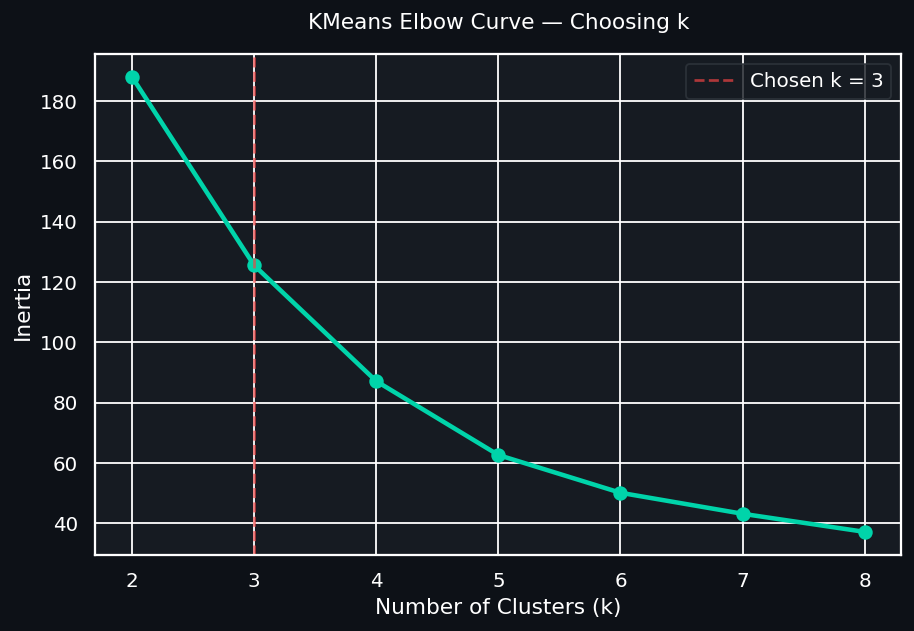


  TEAM TIERS — FULL LIST

STRONG — 74 teams:
                  team    elo_2026  win_rate
                 Spain 1111.700740  0.690000
             Argentina 1044.692141  0.613115
                France 1020.232379  0.616129
               England 1010.793729  0.613475
              Colombia  945.346718  0.460967
               Ecuador  934.526640  0.377289
                Norway  917.437738  0.473251
                Brazil  909.271445  0.632258
           Netherlands  904.958448  0.606498
              Portugal  899.150562  0.586207
               Croatia  886.869375  0.545788
                 Japan  875.127613  0.582237
               Uruguay  872.787519  0.453532
               Germany  870.480228  0.594771
              Paraguay  870.049211  0.319066
               Morocco  844.059738  0.563707
           Switzerland  843.065621  0.474308
                Turkey  826.237870  0.477273
                Mexico  821.107186  0.553134
               Senegal  816.059768  0.561069
         

In [49]:
# SECTION 3 — KMEANS TEAM CLUSTERING ( Model 2 )

#نقسم الفرق الى قويه ومتوسطه وضعيفه عن طريق الكلاسترنق ولانه بدون ليبل بنستخدم انسوبرفايسد ليرننق

print("_" * 60)
print("  SECTION 3 — KMEANS TEAM CLUSTERING")
print("_" * 60)

#KMeans: unsupervised — lets the data itself define tiers. We don't manually label "strong/medium/weak". 3 clusters mirror the natural football hierarchy.

elo_snap = pd.read_csv("elo_snapshot_2026.csv")

#Extra features per team for richer clustering
#ننشئ فيوتشر جديدات
#الwin rate : يحسب لكل فريق نسبه الفوز = عدد الفوز\عدد المباريات
win_rate_all = {}
for team in elo_snap['team']:
    h_wins = len(df[(df['home_team'] == team) & (df['result'] == 2)])
    a_wins = len(df[(df['away_team'] == team) & (df['result'] == 0)])
    played = len(df[(df['home_team'] == team) | (df['away_team'] == team)])
    win_rate_all[team] = (h_wins + a_wins) / played if played > 0 else 0

elo_snap['win_rate'] = elo_snap['team'].map(win_rate_all).fillna(0)
# Add form to clustering features
elo_snap['form'] = elo_snap['team'].map(FORM_DICT).fillna(0.5)

cluster_features = ['elo_2026', 'win_rate']
X_cluster = elo_snap[cluster_features].copy()

#Scale for KMeans (distance-sensitive)
scaler_k = StandardScaler()
X_scaled = scaler_k.fit_transform(X_cluster)

#3 clusters: matches the project brief (Strong/Medium/Weak)
#                 and confirmed by Elbow method
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
elo_snap['cluster'] = kmeans.fit_predict(X_scaled)

#Map cluster IDs to labels by Elo centroid
centroid_elo = elo_snap.groupby('cluster')['elo_2026'].mean().sort_values(ascending=False)
label_map    = {centroid_elo.index[0]: 'Strong',
                centroid_elo.index[1]: 'Medium',
                centroid_elo.index[2]: 'Weak'}
elo_snap['tier'] = elo_snap['cluster'].map(label_map)

print("\nCluster Sizes:")
print(elo_snap['tier'].value_counts().to_string())

print("\nStrong Tier — Top 15 Teams:")
strong = elo_snap[elo_snap['tier'] == 'Strong'].sort_values('elo_2026', ascending=False)
print(strong[['team', 'elo_2026', 'win_rate']].head(15).to_string(index=False))

#Scatter plot: Elo vs Win Rate, colored by cluster
cluster_colors = {'Strong': C_PRIMARY,
                  'Medium': C_SECONDARY,
                  'Weak': C_NEUTRAL}

fig, ax = plt.subplots(figsize=(10, 7))
for tier, grp in elo_snap.groupby('tier'):
    ax.scatter(grp['elo_2026'], grp['win_rate'],
               label=tier, color=cluster_colors[tier],
               alpha=0.75, edgecolors='white', linewidth=0.4, s=60)

ax.set_title('KMeans Clustering — Team Tiers (2026)', pad=14)
ax.set_xlabel('Elo Rating')
ax.set_ylabel('Win Rate')
ax.legend(title='Tier', framealpha=0.3)
save_ml_fig("04_kmeans_clusters")

#Elbow curve (justification for k=3)
inertias = []
K_range  = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(K_range, inertias, color=C_ACCENT,
        linewidth=2.5, marker='o', markersize=7)
ax.axvline(3, linestyle='--', color=C_DANGER,
           alpha=0.7, label='Chosen k = 3')
ax.set_title('KMeans Elbow Curve — Choosing k', pad=14)
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Inertia')
ax.legend()
save_ml_fig("05_elbow_curve")

# اطبع كل الفرق في كل كلستر
print("\n" + "_" * 50)
print("  TEAM TIERS — FULL LIST")
print("_" * 50)

for tier_name, tier_label in [('Strong', 'STRONG'),
                                ('Medium', 'MEDIUM'),
                                ('Weak', 'WEAK')]:
    teams_in_tier = (elo_snap[elo_snap['tier'] == tier_name]
                     .sort_values('elo_2026', ascending=False))
    print(f"\n{tier_label} — {len(teams_in_tier)} teams:")
    print(teams_in_tier[['team', 'elo_2026', 'win_rate']]
          .to_string(index=False))

# Save clustered snapshot for simulator
elo_snap.to_csv("elo_snapshot_clustered.csv", index=False)
print("\n  Section 3 complete — elo_snapshot_clustered.csv saved.\n")


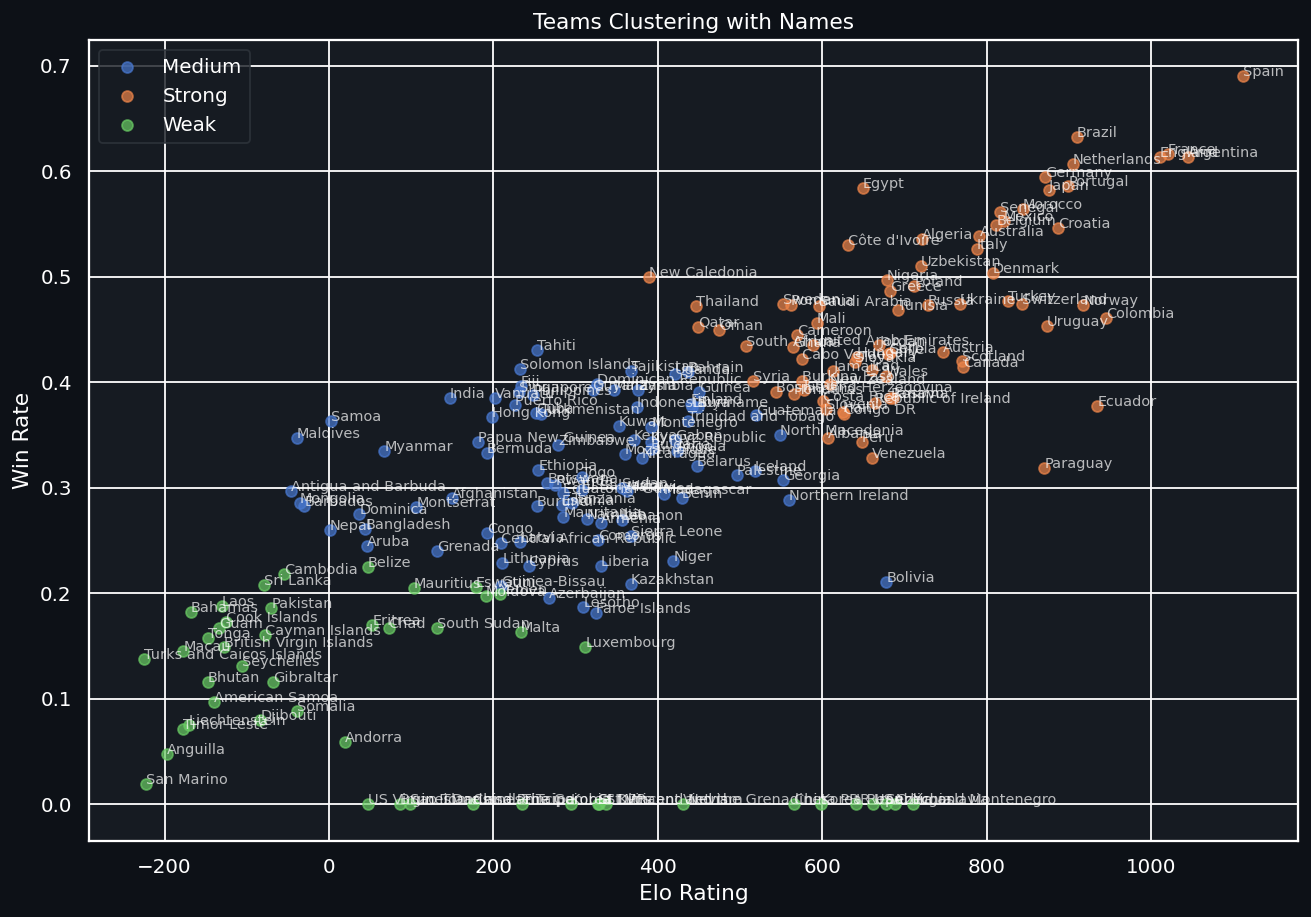

In [50]:
fig, ax = plt.subplots(figsize=(12, 8))

for tier, grp in elo_snap.groupby('tier'):
    ax.scatter(grp['elo_2026'], grp['win_rate'],
               label=tier, alpha=0.7)

    # إضافة أسماء الفرق
    for _, row in grp.iterrows():
        ax.text(row['elo_2026'], row['win_rate'], row['team'],
                fontsize=8, alpha=0.7)

ax.set_title('Teams Clustering with Names')
ax.set_xlabel('Elo Rating')
ax.set_ylabel('Win Rate')
ax.legend()
plt.show()

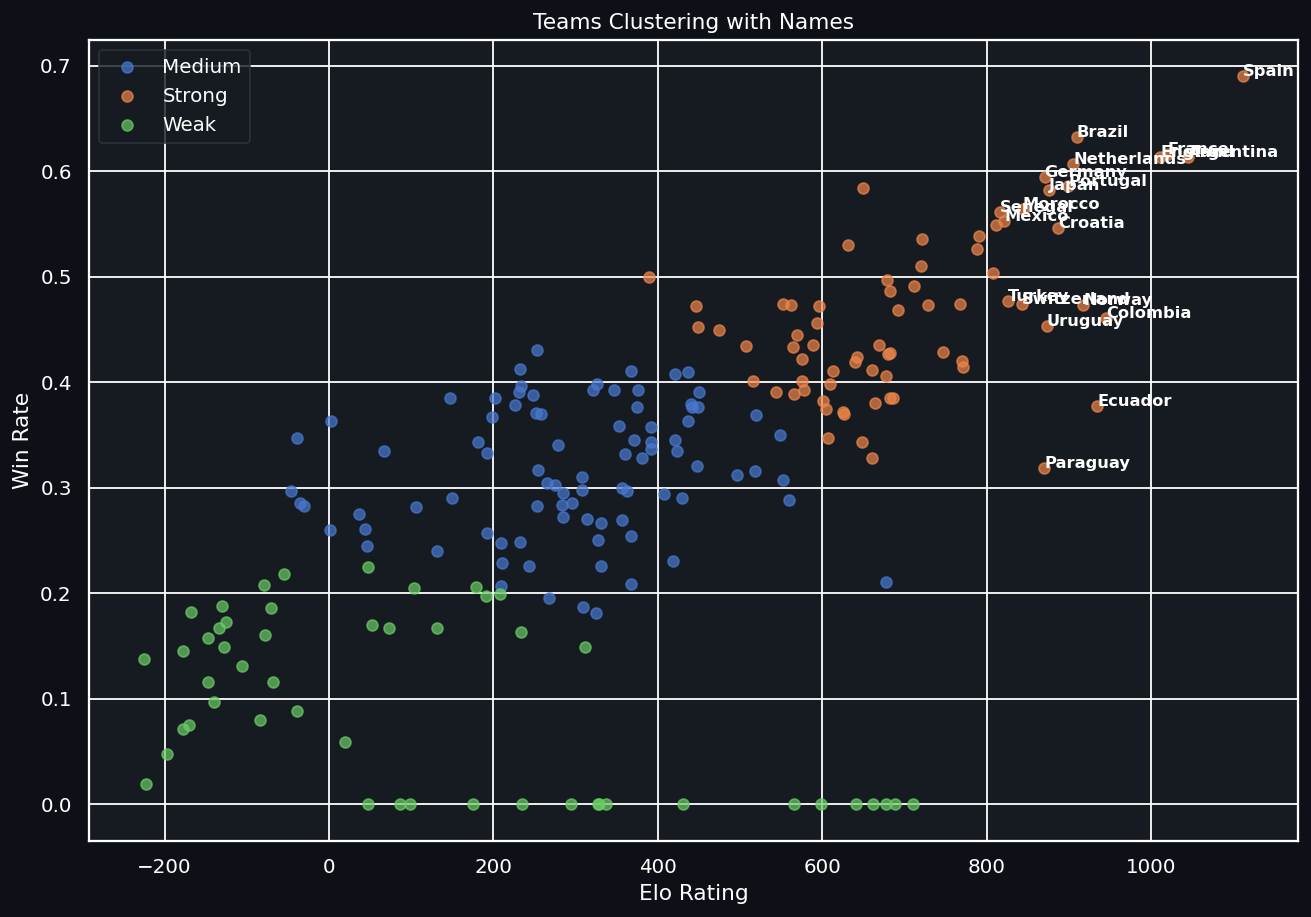

In [58]:
fig, ax = plt.subplots(figsize=(12, 8))

for tier, grp in elo_snap.groupby('tier'):
    ax.scatter(grp['elo_2026'], grp['win_rate'],
               label=tier, alpha=0.7)

top_teams = elo_snap.sort_values('elo_2026', ascending=False).head(20)

for _, row in top_teams.iterrows():
    ax.text(row['elo_2026'], row['win_rate'], row['team'],
            fontsize=9, fontweight='bold')

ax.set_title('Teams Clustering with Names')
ax.set_xlabel('Elo Rating')
ax.set_ylabel('Win Rate')
ax.legend()
plt.show()

Insight :

The clustering results show clear separation between strong and weak teams, validating the effectiveness of Elo ratings.

Note:
Feature scaling is essential for KMeans because it relies on distance calculations

##SECTION 4 — UPSET PREDICTION (Model 3)

This section focuses on predicting upsets — cases where the weaker team defeats the stronger team.

We convert the problem into a binary classification task (Upset vs Not Upset).
This helps answer an important football question: when do surprises happen?


____________________________________________________________
  SECTION 4 ( Model 3 ) — UPSET PREDICTION MODEL
____________________________________________________________

  Upset Model — Accuracy: 0.777  F1: 0.731
  Upset rate in test set: 22.5%
   Saved: ml_plots/06_upset_feature_importance.png


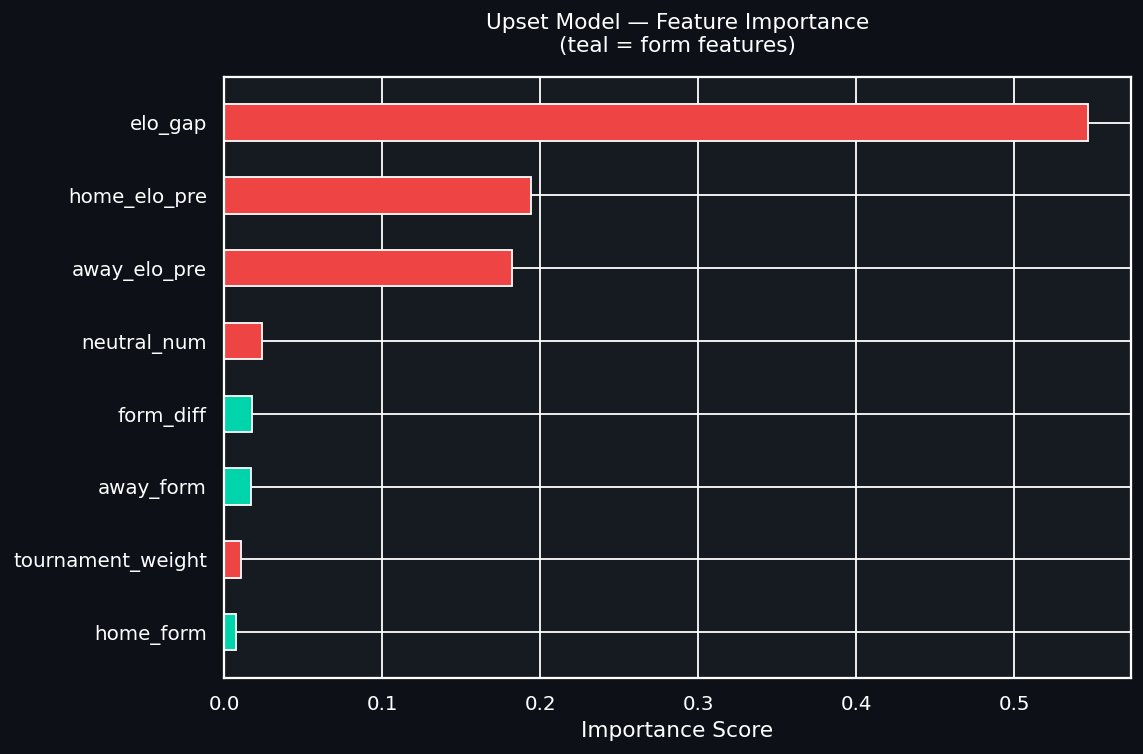


  Section 4 complete.



In [44]:
# SECTION 4 — UPSET PREDICTION MODEL ( Model 3 )

#نحول المشكله لكلسفكيشن اذا فيه مفاجئه الابست بيكون بحواد اذا مافيه بيكون بصفر
print("_" * 60)
print("  SECTION 4 ( Model 3 ) — UPSET PREDICTION MODEL")
print("_" * 60)

#separate binary model for upsets , answers the EDA question "can we predict WHEN the underdog wins?"

#نسوي فيوتشر جديد الفرق في القوه . اذا فرق كبير 200 اذا صغير 20 وهذا بيكون عامل المفاجئه
df['elo_gap']     = df['elo_diff'].abs()
#نحدد الفريق اللي متوقعين يفوز
df['favorite_won'] = (
    ((df['elo_diff'] > 0) & (df['result'] == 2)) |
    ((df['elo_diff'] < 0) & (df['result'] == 0))
)# elo_diff > 0 صاحب الأرض أقوى
# result == 2 وفاز
#يعني التوقع صحيح
#upset = 1 when underdog wins, 0 otherwise
#اذا الفريق الاقوى ما فاز هنا يحدث مفاجئه
df['is_upset'] = (~df['favorite_won']).astype(int)
#exclude draws (ambiguous — neither team is the favorite winner)
df_upset = df[df['result'] != 1].copy()#نستبعد التعادل لان لا القوي فاز ولا الضعيف فاز

UPSET_FEATURES = ['elo_gap', 'home_elo_pre', 'away_elo_pre',
                  'neutral_num', 'tournament_weight',
                  'home_form', 'away_form', 'form_diff'] #اذا الايلو_قاب زاد يعني المفاجئات تقل
                  # form_diff : الفريق اللي فورمه أفضل ممكن يفاجئ
                  #neutral :  ملعب محايد = مفاجآت أكثر
#Train/Test Split
train_u = df_upset[df_upset['date'] < SPLIT_DATE]
test_u  = df_upset[df_upset['date'] >= SPLIT_DATE]

X_tu = train_u[UPSET_FEATURES]; y_tu = train_u['is_upset']
X_vu = test_u[UPSET_FEATURES];  y_vu = test_u['is_upset']

#نبني المودل
#سبب اختيارنا لل Gradient Boosting
#ممتاز في الباترين المعقده والعلاقات غير الخطيه وللمفاجئات
upset_model = GradientBoostingClassifier(
    n_estimators=200, max_depth=4,
    learning_rate=0.05, random_state=42
)
upset_model.fit(X_tu, y_tu)
y_pred_u = upset_model.predict(X_vu)

acc_u = accuracy_score(y_vu, y_pred_u)
f1_u  = f1_score(y_vu, y_pred_u, average='weighted')
print(f"\n  Upset Model — Accuracy: {acc_u:.3f}  F1: {f1_u:.3f}")
print(f"  Upset rate in test set: {y_vu.mean():.1%}")#هنا يعلمنا كم عدد المفاجئات في الداتا حقتنا

#Feature importance
#هالفيتشر بيجاوب لنا عن ليش تصير مفاجئات
#elo_gap → الأعلى
#form_diff → مهم
#neutral → متوسط
imp_u = pd.DataFrame({'Feature':    UPSET_FEATURES,
                       'Importance': upset_model.feature_importances_}
                     ).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
bar_colors_u = [C_ACCENT if 'form' in f else C_DANGER for f in imp_u['Feature']]
ax.barh(imp_u['Feature'], imp_u['Importance'],
        color=bar_colors_u, edgecolor='white', height=0.5)
ax.set_title('Upset Model — Feature Importance\n(teal = form features)', pad=14)
ax.set_xlabel('Importance Score')
save_ml_fig("06_upset_feature_importance")
print("\n  Section 4 complete.\n")




Insight :

Even with a strong Elo gap, upsets still occur, proving that football contains inherent randomness.

Note:
Draws are excluded because they do not clearly indicate whether the favorite or underdog succeeded.


##SECTION 5 — GOAL PREDICTION (Model 4)

In this section, we predict the number of goals scored using regression models.

We use Poisson Regression because goals are count data, and compare it with Random Forest Regressor.
Separate models are built for home and away teams to capture asymmetric behavior.


In [45]:
# SECTION 5 ( Model 4 ) — GOAL PREDICTION MODEL (Poisson)

#دمجت بين المشين ليرننق و ال poisson regression
#poisson regression مودل احصائي مبني على فرضيه :
#الأهداف = count data → تتبع توزيع Poisson

#2 random forest regressor
#مايعتمد على التوزيع ويتعلم الباترين من البيانات مباشره
print("_" * 60)
print("  SECTION 5 ( Model 4 ) — GOAL PREDICTION MODEL")
print("_" * 60)

#Poisson Regression: goals are count data — Poisson is the statistically correct distribution for count outcomes. Random Forest Regressor added as a non-parametric comparison.

from sklearn.ensemble  import RandomForestRegressor
from sklearn.metrics   import mean_absolute_error, mean_squared_error

GOAL_FEATURES = ['home_elo_pre', 'away_elo_pre', 'elo_diff',
                 'neutral_num', 'tournament_weight',
                 'home_form', 'away_form']

# Train two models: home goals and away goals separately
#a team's attack vs the opponent's defense interact asymmetrically — two separate models is more accurate

for side, score_col in [('Home', 'home_score'), ('Away', 'away_score')]:
    X_tr_g = train_df[GOAL_FEATURES]; y_tr_g = train_df[score_col]
    X_te_g = test_df[GOAL_FEATURES];  y_te_g = test_df[score_col]

    #Poisson
    poisson_model = PoissonRegressor(max_iter=500)
    poisson_model.fit(X_tr_g, y_tr_g)
    mae_p = mean_absolute_error(y_te_g, poisson_model.predict(X_te_g))


    #Random Forest Regressor
    rf_reg = RandomForestRegressor(n_estimators=200, max_depth=6,
                                   random_state=42, n_jobs=-1)
    rf_reg.fit(X_tr_g, y_tr_g)
    y_pred_r = rf_reg.predict(X_te_g)
    mae_r = mean_absolute_error(y_te_g, rf_reg.predict(X_te_g))

#Model Selection (Auto Selection) النظام يختار الافضل بنفسه مو انا اللي فرضت مودل واحد
    print(f"  {side} Goals — Poisson MAE: {mae_p:.3f}   RF MAE: {mae_r:.3f}")
    if side == 'Home':
        home_goal_model = poisson_model if mae_p <= mae_r else rf_reg
    else:
        away_goal_model = poisson_model if mae_p <= mae_r else rf_reg

def predict_scoreline(home_elo, away_elo,
                      home_form=0.5, away_form=0.5,
                      neutral=False, tournament='Friendly'):
    t_w  = get_k_factor(tournament)
    diff = home_elo - away_elo
    X    = pd.DataFrame([[home_elo, away_elo, diff,
                          int(neutral), t_w, home_form, away_form]],
                        columns=GOAL_FEATURES)
    hg = max(0, home_goal_model.predict(X)[0])
    ag = max(0, away_goal_model.predict(X)[0])
    return round(hg, 1), round(ag, 1)

____________________________________________________________
  SECTION 5 ( Model 4 ) — GOAL PREDICTION MODEL
____________________________________________________________


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: invalid value encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights


  Home Goals — Poisson MAE: 1.183   RF MAE: 1.024


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: invalid value encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights


  Away Goals — Poisson MAE: 0.890   RF MAE: 0.837


Insight :

Poisson regression provides realistic goal distributions, making it ideal for simulation.

Note:
This model is NOT used directly inside the simulation loop because it is too slow.

##SECTION 6 — MONTE CARLO SIMULATION (Model 5)

In this section, we simulate the FIFA World Cup 2026 using Monte Carlo simulation.

Instead of predicting a single outcome, we simulate the entire tournament thousands of times to estimate probabilities.
This approach captures uncertainty and randomness in football.

In [46]:
# SECTION 6 — WORLD CUP 2026 SIMULATOR  (Model 5)

#هنا نظام محاكاه كامل
#بنيت Hybrid Prediction Engine
#Fast model (Elo + Form) → لكل المباريات
#ML model → للأدوار المهمة (SF + Final)
#هالتصميم يعتبر Computational Optimization Strategy

print("_" * 60)
print("  SECTION 6 (Model 5) — WORLD CUP 2026 SIMULATOR")
print("_" * 60)

# Official 2026 Groups
WC2026_GROUPS = {
    'A': ['Mexico',      'South Korea',        'South Africa',  'Czech Republic'],
    'B': ['Canada',      'Bosnia-Herzegovina', 'Qatar',         'Switzerland'],
    'C': ['Brazil',      'Morocco',            'Haiti',         'Scotland'],
    'D': ['USA',         'Paraguay',           'Australia',     'Turkey'],
    'E': ['Germany',     'Curaçao',            "Côte d'Ivoire", 'Ecuador'],
    'F': ['Netherlands', 'Japan',              'Sweden',        'Tunisia'],
    'G': ['Belgium',     'Egypt',              'Iran',          'New Zealand'],
    'H': ['Spain',       'Cabo Verde',         'Saudi Arabia',  'Uruguay'],
    'I': ['France',      'Senegal',            'Iraq',          'Norway'],
    'J': ['Argentina',   'Algeria',            'Austria',       'Jordan'],
    'K': ['Portugal',    'Congo DR',           'Uzbekistan',    'Colombia'],
    'L': ['England',     'Croatia',            'Ghana',         'Panama'],
}

# df_shootouts defined here
df_shootouts = pd.read_csv("shootouts.csv")
df_shootouts['date'] = pd.to_datetime(df_shootouts['date'])
df_shootouts = df_shootouts[df_shootouts['date'] >= '2002-01-01']

# O(1) dict lookup , eliminates DataFrame scan inside the loop
#اجهز البيانات داخل السيستم هنا حولت من داتافريم الى ديكشنري
ELO_DICT  = dict(zip(elo_snap['team'], elo_snap['elo_2026']))
_ELO_AVG  = float(elo_snap['elo_2026'].mean())

# Validate all WC teams exist in Elo snapshot
all_wc_teams = [t for teams in WC2026_GROUPS.values() for t in teams]
missing_elo  = [t for t in all_wc_teams if t not in ELO_DICT]
if missing_elo:
    print(f"   Missing Elo for: {missing_elo} — using world average")
else:
    print("  All 48 WC teams found in Elo snapshot")

#لو الفريق مو موجود يعطيه متوسط العالم , هنا عشان نحمي السيستم ما ينهار
def get_team_elo(team):
    return ELO_DICT.get(team, _ELO_AVG)

def get_team_form(team):
    return FORM_DICT.get(team, 0.5)
#نعتمد على البيانات التاريخيه ويحسب البروباليتي ويختار عشوائي وهذا يعطي واقعيه
def get_shootout_winner(team1, team2):
    wins1 = len(df_shootouts[df_shootouts['winner'] == team1])
    wins2 = len(df_shootouts[df_shootouts['winner'] == team2])
    total = wins1 + wins2
    p1    = wins1 / total if total > 0 else 0.5
    return team1 if np.random.random() < p1 else team2

# Core simulation functions
#هذا المحاكاه وهو اهم شي
def simulate_match(team1, team2, neutral=True, knockout=False,
                   use_ml=False):
    """
    use_ml=True  → full ML model (for SF + Final only)
    use_ml=False → fast Elo + Form formula (for all other rounds)
    """
    #تجيب الفيتشر
    elo1  = get_team_elo(team1);  elo2  = get_team_elo(team2)
    form1 = get_team_form(team1); form2 = get_team_form(team2)

    if use_ml:
        # Full ML prediction — used only in SF and Final (4 matches total)
        # Normalize to fix sklearn floating point drift (sum may be 0.9999...)
        #تختار مودل
        probs = predict_match_ml(elo1, elo2,
                         home_form=form1, away_form=form2,
                         neutral=neutral,
                         tournament='FIFA World Cup')
        probs  = np.array(probs, dtype=np.float64)
        probs  = probs / probs.sum()
        p_away, p_draw, p_home = probs[0], probs[1], probs[2]
    else:
        # Fast Elo + Form — used for all other rounds
        p_home, p_draw, p_away = predict_match_fast(
            elo1, elo2, form1, form2, neutral)

    p_arr   = np.array([p_home, p_draw, p_away], dtype=np.float64)
    p_arr   = p_arr / p_arr.sum()   # normalize — float precision safety
    #القرار الحقيقي وهنا ياخذ بناء على الاحتمال
    outcome = np.random.choice([2, 1, 0], p=p_arr)

    if outcome == 2:   return team1, 3, 0
    elif outcome == 0: return team2, 0, 3
    else:
      #لو مافيه تعادل يحسمها بركلات الترجيح
        if knockout:
            return get_shootout_winner(team1, team2), None, None
        return None, 1, 1
#دور المجموعات : كل فريق يلعب مع كل الفرق ونطلع نقاط فوز3 و تعادل1 و خساره1
def simulate_group(teams):
    """
    Round-robin group stage.
    Fix: draw points handled correctly via winner check.
    """
    standings = {t: {'pts': 0, 'gd': 0, 'gf': 0} for t in teams}

    for i in range(len(teams)):
        for j in range(i + 1, len(teams)):
            h, a = teams[i], teams[j]
            winner, pts_h, pts_a = simulate_match(h, a, neutral=True)

            # points assignment
            if winner is None:       # draw
                standings[h]['pts'] += 1
                standings[a]['pts'] += 1
            elif winner == h:
                standings[h]['pts'] += 3
            else:
                standings[a]['pts'] += 3

            # Fast inline goal estimate (Poisson model not used in loop)
            diff_ratio = (get_team_elo(h) - get_team_elo(a)) / 400
            hg = max(0, int(round(1.5 + diff_ratio * 0.5)))
            ag = max(0, int(round(1.2 - diff_ratio * 0.5)))

            standings[h]['gf'] += hg;  standings[a]['gf'] += ag
            standings[h]['gd'] += (hg - ag)
            standings[a]['gd'] += (ag - hg)

    ranked = sorted(teams, key=lambda t: (
        -standings[t]['pts'], -standings[t]['gd'], -standings[t]['gf']))
    return ranked, standings
#القروب ستيج نطلع افضل الثوالث
def run_tournament():
    advancement = {t: 0 for group in WC2026_GROUPS.values() for t in group}

    # Group Stage
    group_winners, group_runners, group_thirds = [], [], []
    for grp, teams in WC2026_GROUPS.items():
        ranked, standings = simulate_group(teams)
        group_winners.append(ranked[0])
        group_runners.append(ranked[1])
        group_thirds.append((ranked[2],
                             standings[ranked[2]]['pts'],
                             standings[ranked[2]]['gd']))

    group_thirds.sort(key=lambda x: (-x[1], -x[2]))
    best_thirds = [t[0] for t in group_thirds[:8]]
    r32_teams   = group_winners + group_runners + best_thirds
    np.random.shuffle(r32_teams)

    for t in r32_teams:
        advancement[t] = max(advancement.get(t, 0), 1)

    # Knockout Rounds — R32 / R16 / QF use ML
    current_round = r32_teams[:]
    all_rounds  = ['Round of 32', 'Round of 16', 'Quarter-finals']

    for rnd_name in all_rounds:
        next_round = []
        np.random.shuffle(current_round)
        for k in range(0, len(current_round), 2):
            if k + 1 < len(current_round):
                winner, _, _ = simulate_match(
                    current_round[k], current_round[k+1],
                    neutral=True, knockout=True, use_ml=True)
                next_round.append(winner)
        current_round = next_round

    # Semi-finals — ML model
    sf_teams = current_round[:]
    np.random.shuffle(sf_teams)
    finalists = []
    for k in range(0, len(sf_teams), 2):
        if k + 1 < len(sf_teams):
            winner, _, _ = simulate_match(
                sf_teams[k], sf_teams[k+1],
                neutral=True, knockout=True, use_ml=True)   # ← ML
            finalists.append(winner)

    # Final — ML model
    if len(finalists) >= 2:
        champion, _, _ = simulate_match(
            finalists[0], finalists[1],
            neutral=True, knockout=True, use_ml=True)       # ← ML
        advancement[champion] = max(advancement.get(champion, 0), 6)
        return champion, advancement

    return finalists[0] if finalists else None, advancement

#  Monte Carlo × 1000
# فكرته اننا نشغل البطوله 1000 مره وناخذ احتمالات الفوز الحقيقيه وهذا الكونسبت يسونه الشركات في التحليل الرياضس
N_SIMULATIONS = 5000
print(f"\nRunning {N_SIMULATIONS:,} Monte Carlo simulations...")
print("Monte Carlo Simulations | Full ML Model — All Rounds \n")

win_counts = {}
for sim in range(N_SIMULATIONS):
    if sim % 200 == 0:
        print(f"   Simulation {sim}/{N_SIMULATIONS}...")
    champion, _ = run_tournament()
    win_counts[champion] = win_counts.get(champion, 0) + 1

print(f"\n   Done!")

win_df = (pd.DataFrame(list(win_counts.items()),
                        columns=['team', 'wins'])
           .sort_values('wins', ascending=False)
           .reset_index(drop=True))
win_df['probability'] = win_df['wins'] / N_SIMULATIONS

print("\n   World Cup 2026 Win Probabilities (Top 15):")
print("  " + "─" * 40)
for _, row in win_df.head(15).iterrows():
    bar = "█" * int(row['probability'] * 40)
    print(f"  {row['team']:<22s}  {row['probability']:.1%}  {bar}")





____________________________________________________________
  SECTION 6 (Model 5) — WORLD CUP 2026 SIMULATOR
____________________________________________________________
   Missing Elo for: ['South Korea', 'Czech Republic', 'Bosnia-Herzegovina', 'Curaçao', 'Iran'] — using world average

Running 5,000 Monte Carlo simulations...
Monte Carlo Simulations | Full ML Model — All Rounds 

   Simulation 0/5000...
   Simulation 200/5000...
   Simulation 400/5000...
   Simulation 600/5000...
   Simulation 800/5000...
   Simulation 1000/5000...
   Simulation 1200/5000...
   Simulation 1400/5000...
   Simulation 1600/5000...
   Simulation 1800/5000...
   Simulation 2000/5000...
   Simulation 2200/5000...
   Simulation 2400/5000...
   Simulation 2600/5000...
   Simulation 2800/5000...
   Simulation 3000/5000...
   Simulation 3200/5000...
   Simulation 3400/5000...
   Simulation 3600/5000...
   Simulation 3800/5000...
   Simulation 4000/5000...
   Simulation 4200/5000...
   Simulation 4400/5000...
 

   Saved: ml_plots/07_wc2026_monte_carlo.png


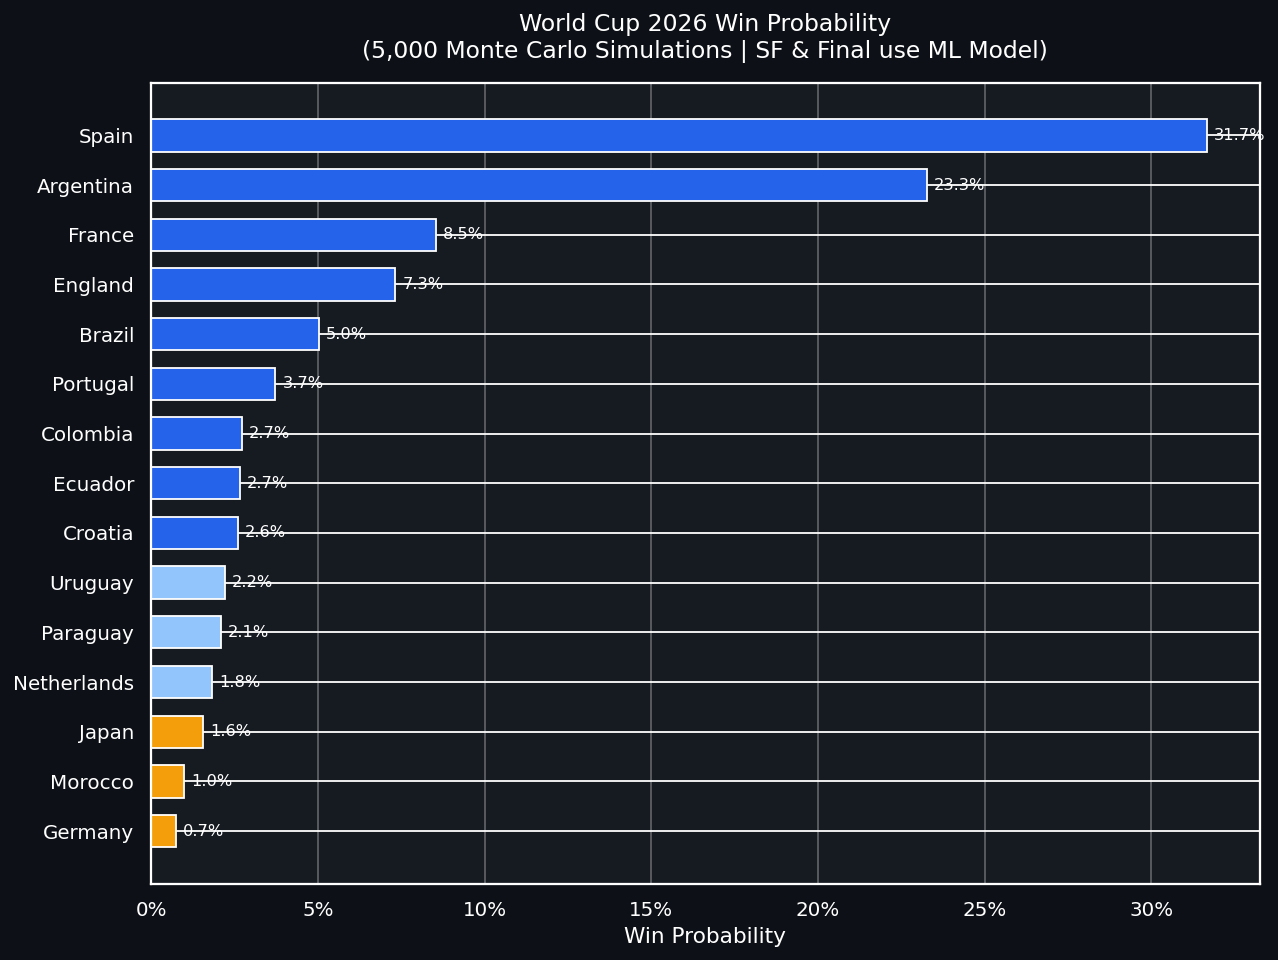

   Saved: wc2026_win_probabilities.csv


In [47]:
# Bar Chart
top15 = win_df.head(15).sort_values('probability')
bar_colors_mc = [C_SECONDARY if i >= 12 else
                 C_LIGHT     if i >= 9  else
                 C_PRIMARY   for i in range(len(top15))]
fig, ax = plt.subplots(figsize=(11, 8))
bars = ax.barh(top15['team'], top15['probability'],
               color=bar_colors_mc[::-1], edgecolor='white', height=0.65)
ax.bar_label(bars,
             labels=[f'{v:.1%}' for v in top15['probability']],
             padding=4, color='white', fontsize=9)
ax.set_title(
    f'World Cup 2026 Win Probability\n'
    f'({N_SIMULATIONS:,} Monte Carlo Simulations | SF & Final use ML Model)',
    fontsize=13, pad=14)
ax.set_xlabel('Win Probability')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.grid(axis='x', alpha=0.3)
save_ml_fig("07_wc2026_monte_carlo")

win_df.to_csv("wc2026_win_probabilities.csv", index=False)
print("   Saved: wc2026_win_probabilities.csv")

Insight :
Even with large Elo differences, upsets still happen.
That’s why Monte Carlo simulation is essential , it captures real-world randomness.

How it works:

Calculate probabilities using Elo
Randomly simulate match outcomes
Repeat the tournament 1000 times

Note:
A fast Elo-based function is used instead of ML models to keep the simulation computationally efficient.

In [59]:
# SECTION 7 — FINAL SUMMARY
print("\n" + "_" * 60)
print("  SECTION 7 — MODEL SUMMARY")
print("_" * 60)

summary = {
    'Best Classifier':         best_model_name,
    'Classifier Accuracy':     f"{results_df.iloc[0]['Accuracy']:.3f}",
    'Classifier F1':           f"{results_df.iloc[0]['F1 Score']:.3f}",
    'Upset Model Accuracy':    f"{acc_u:.3f}",
    'KMeans Strong Teams': str(len(elo_snap[elo_snap['tier'] == 'Strong'])),
    'KMeans Medium Teams': str(len(elo_snap[elo_snap['tier'] == 'Medium'])),
    'KMeans Weak Teams':   str(len(elo_snap[elo_snap['tier'] == 'Weak'])),
    'Monte Carlo Simulations': f"{N_SIMULATIONS:,}",
    'Simulator Strategy':       f'Full {best_model_name} — All Rounds (ML)',
    'Predicted WC Champion':   win_df.iloc[0]['team'],
    'Champion Probability':    f"{win_df.iloc[0]['probability']:.1%}",
}

for k, v in summary.items():
    print(f"   {k:<32s}: {v}")

print("\n" + "_" * 60)
print("   PART 2 COMPLETE")
print("_" * 60)



____________________________________________________________
  SECTION 7 — MODEL SUMMARY
____________________________________________________________
   Best Classifier                 : XGBoost
   Classifier Accuracy             : 0.595
   Classifier F1                   : 0.531
   Upset Model Accuracy            : 0.777
   KMeans Strong Teams             : 74
   KMeans Medium Teams             : 88
   KMeans Weak Teams               : 50
   Monte Carlo Simulations         : 5,000
   Simulator Strategy              : Full XGBoost — All Rounds (ML)
   Predicted WC Champion           : Spain
   Champion Probability            : 31.7%

____________________________________________________________
   PART 2 COMPLETE
____________________________________________________________
